# Maintenance prédictive – Détection de pannes machine (AI4I 2020)

## Objectif
Détecter des comportements anormaux sur des machines industrielles à partir des mesures de capteurs, en particulier avec un **auto-encodeur non supervisé** entraîné uniquement sur les observations normales.

Le notebook contient aussi une comparaison avec **Isolation Forest** et un **réseau de neurones supervisé (ANN)**. Cette comparaison sert à contextualiser les performances ; elle ne change pas le caractère non supervisé de la méthode principale.

## Audit et corrections appliquées
Cette version a été auditée pour vérifier la cohérence méthodologique, les fuites de données, la reproductibilité, l'encodage des variables et la sauvegarde pour une future utilisation.

Principales corrections :
- ajout d'une gestion reproductible des graines aléatoires (`random_state`, NumPy et TensorFlow) ;
- chargement des données plus robuste pour Colab et hors Colab ;
- remplacement de `LabelEncoder` par un **one-hot encoding** de `Type`, car `Type` est une variable catégorielle nominale ;
- calcul dynamique du nombre de variables d'entrée du réseau, au lieu de supposer `11` ;
- clarification de la séparation **entraînement normal / validation normale / test final** ;
- conservation du seuil de l'auto-encodeur calculé uniquement à partir des erreurs des données normales d'entraînement ;
- correction des commentaires qui indiquaient à tort un bottleneck de 4 alors que le modèle utilisait 2 ;
- sauvegarde de l'ordre des variables avec le scaler et le seuil, indispensable pour reproduire l'inférence ;
- ajout d'une conclusion orientée projet et rappel que, pour une détection d'anomalies, le **recall, la precision, le F1 et le PR-AUC** sont plus informatifs que l'accuracy seule.

> Les résultats affichés dans l'ancienne version sont conservés uniquement comme trace de l'exécution précédente. Après modification des cellules, il faut **Exécuter tout** dans Colab pour obtenir les nouveaux résultats cohérents avec cette version.

In [1]:
# Montage Google Drive si le notebook est exécuté sur Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Environnement hors Colab : montage Google Drive ignoré.")

Mounted at /content/drive


## 1. Import des bibliothèques

In [2]:
import os
import random
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Reproductibilité
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Seed globale : {SEED}")

Seed globale : 42


## 2. Chargement des données

In [3]:
# Chemins compatibles Colab et exécution locale
candidate_paths = [
    "/content/drive/MyDrive/Colab Notebooks/PROJET_DL/ai4i2020.csv",
    "ai4i2020.csv",
    "/content/ai4i2020.csv",
]

DATA_PATH = next((p for p in candidate_paths if os.path.exists(p)), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Le fichier ai4i2020.csv est introuvable. "
        "Placez-le dans le dossier du notebook ou adaptez DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print("Fichier :", DATA_PATH)
print("Dimensions :", df.shape)
df.head()

Fichier : /content/drive/MyDrive/Colab Notebooks/PROJET_DL/ai4i2020.csv
Dimensions : (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Exploration initiale du jeu de données

On vérifie la structure des données, les types de variables, les valeurs manquantes et les doublons avant toute analyse.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
# Doublons
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


In [7]:
# Valeurs manquantes
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [8]:
# Nombre de valeurs uniques par colonne
df.nunique()

,0
UDI,10000
Product ID,10000
Type,3
Air temperature [K],93
Process temperature [K],82
Rotational speed [rpm],941
Torque [Nm],577
Tool wear [min],246
Machine failure,2
TWF,2


## 4. Distribution de la variable cible `Machine failure`

Le jeu de données est fortement déséquilibré : les pannes sont rares par rapport aux observations normales. C'est cette caractéristique qui motive l'approche par auto-encodeur (détection d'anomalies).

In [9]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [10]:
failure_percentages = (
    df['Machine failure']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)
failure_percentages

,proportion
Machine failure,
0,96.61
1,3.39


/tmp/ipykernel_3180/2092371953.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


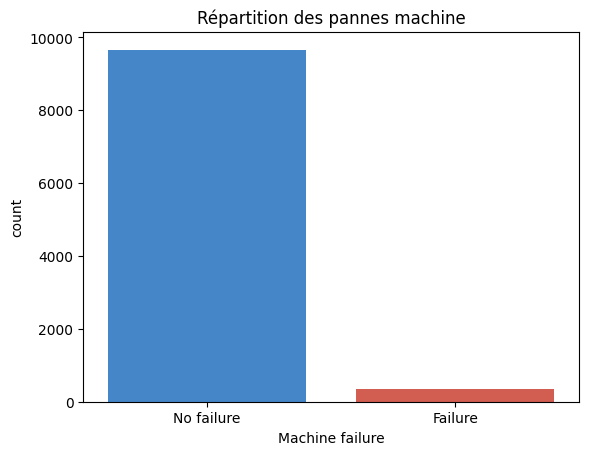

In [11]:
sns.countplot(
    data=df,
    x=df['Machine failure'],
    palette=["#2E86DE", "#E74C3C"],
)
plt.xticks(
    ticks=[0, 1],
    labels=["No failure", "Failure"],
)
plt.title("Répartition des pannes machine")
plt.show()

## 5. Analyse des types de pannes

Le dataset détaille 5 modes de défaillance : usure de l'outil (TWF), dissipation thermique (HDF), surcharge électrique (PWF), surcharge mécanique (OSF) et panne aléatoire (RNF).

In [12]:
FAILURE_COLUMNS = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
]

In [13]:
df[FAILURE_COLUMNS].sum()

,0
TWF,46
HDF,115
PWF,95
OSF,98
RNF,19


/tmp/ipykernel_3180/397430709.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=failure_sums.index, y=failure_sums.values, palette="viridis")


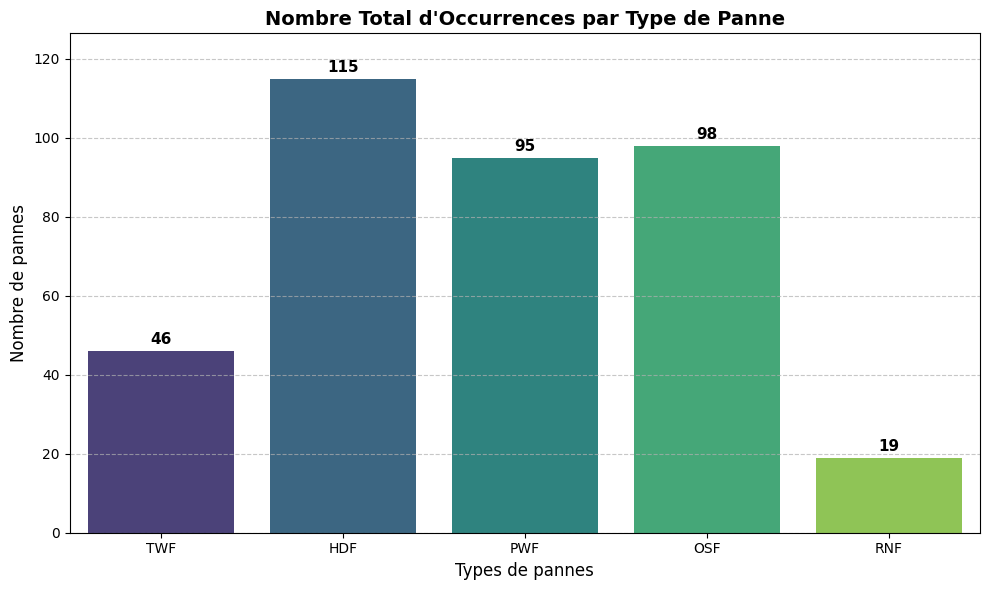

In [14]:
# 1. Calculer la somme
failure_sums = df[FAILURE_COLUMNS].sum()

# 2. Créer le graphique
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=failure_sums.index, y=failure_sums.values, palette="viridis")

# 3. Afficher chaque valeur au-dessus des barres
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11, fontweight="bold")

# 4. Personnaliser l'affichage
plt.title("Nombre Total d'Occurrences par Type de Panne", fontsize=14, fontweight="bold")
plt.xlabel("Types de pannes", fontsize=12)
plt.ylabel("Nombre de pannes", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Laisser de la place en haut pour les chiffres
plt.ylim(0, failure_sums.max() * 1.1)

# 5. Afficher le graphique
plt.tight_layout()
plt.show()

## 6. Analyse de la variable `Type`

In [15]:
df['Type'].value_counts()

,count
Type,
L,6000
M,2997
H,1003


/tmp/ipykernel_3180/2544202074.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


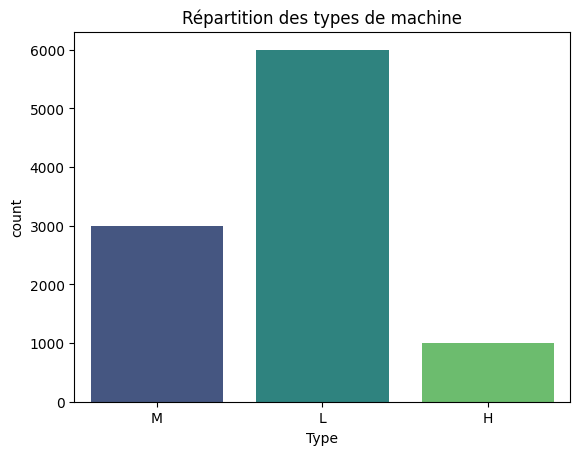

In [16]:
sns.countplot(
    data=df,
    x=df['Type'],
    palette="viridis",
)
plt.title("Répartition des types de machine")
plt.show()

## 7. Sélection des variables pertinentes

On conserve les variables numériques de capteurs, le type de machine et la cible `Machine failure`. Les colonnes d'identifiants (`UDI`, `Product ID`) et les sous-types de panne détaillés ne sont pas utilisés pour la modélisation.

In [17]:
df = df[['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']]
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


## 8. Visualisation des relations entre variables

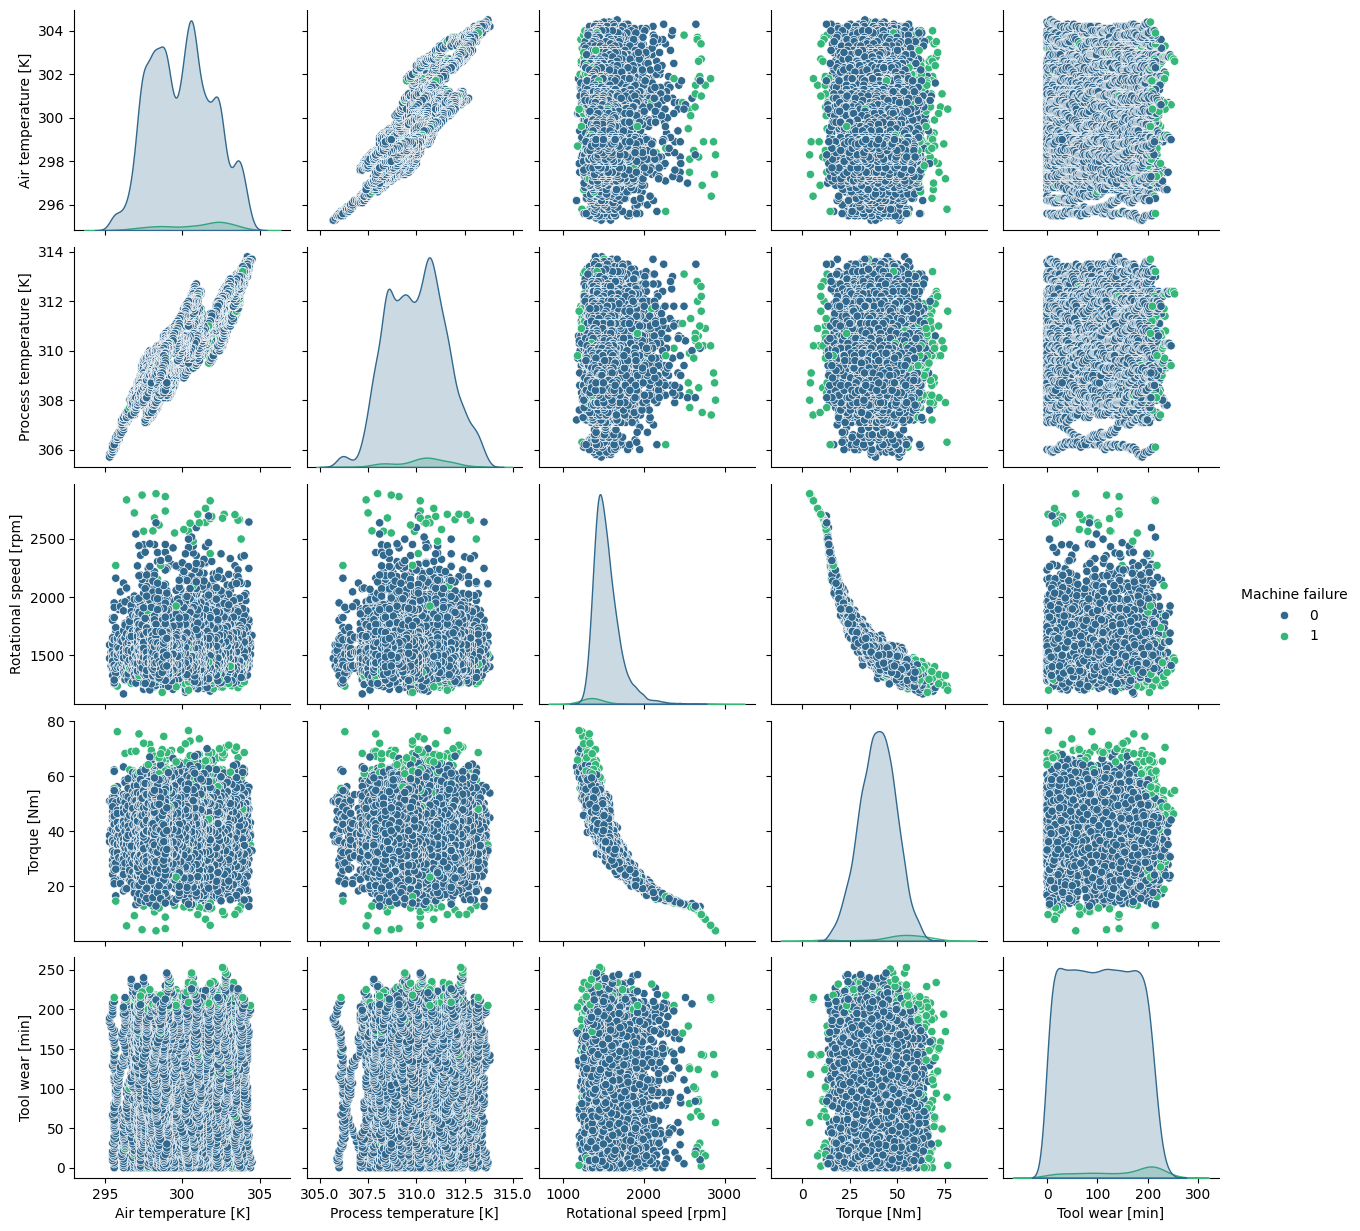

In [18]:
sns.pairplot(df, hue="Machine failure", palette="viridis")
plt.show()

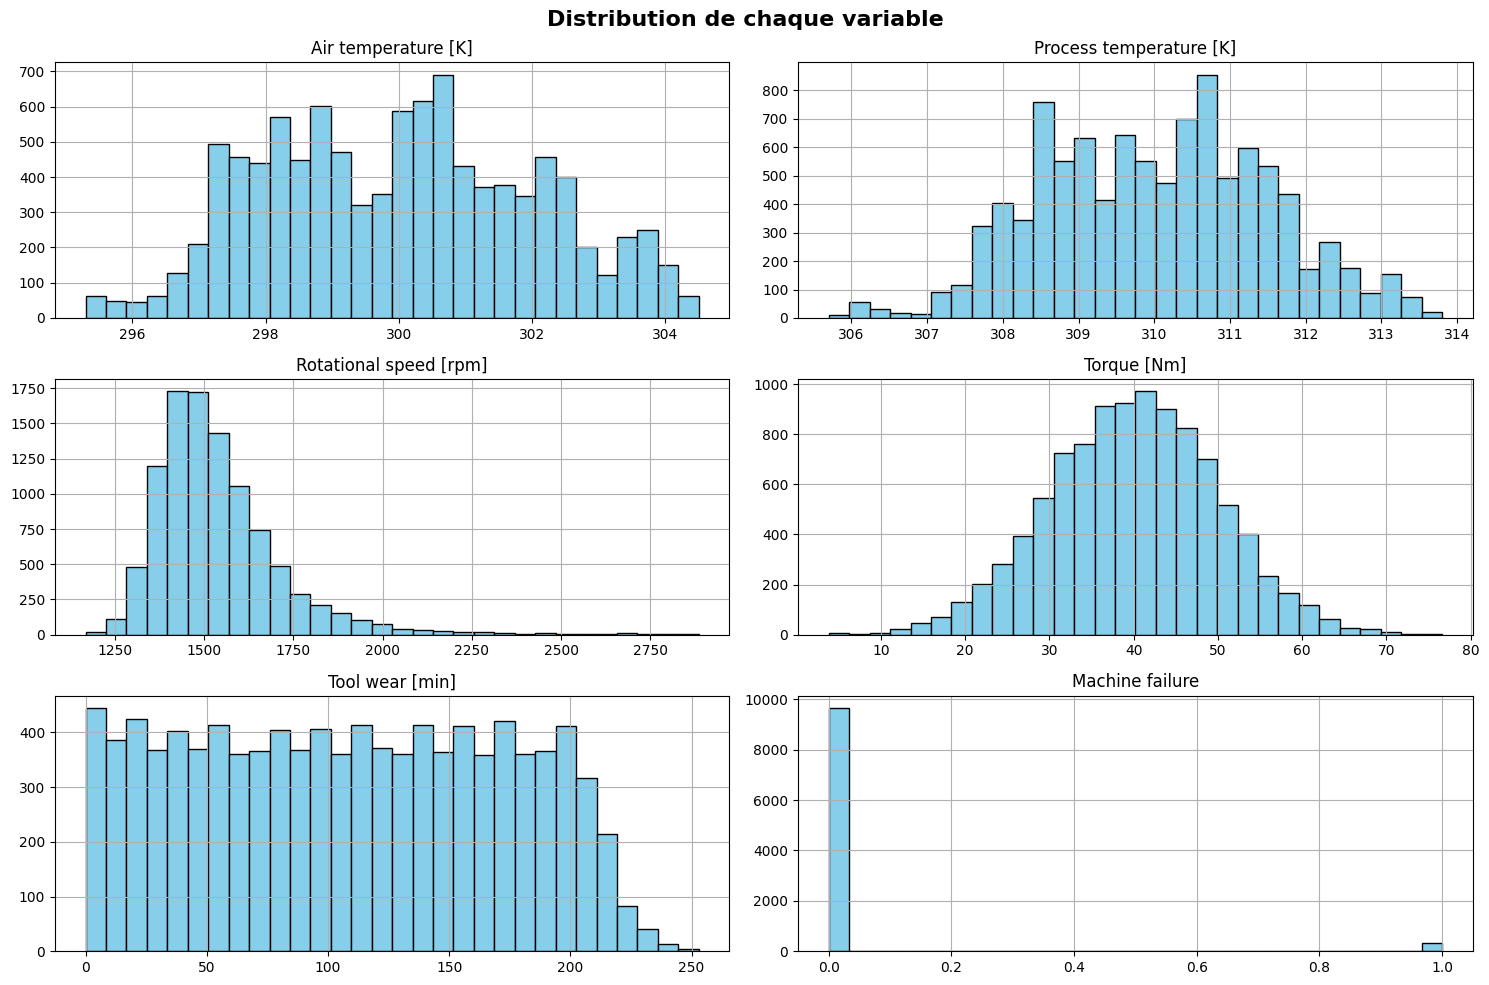

In [19]:
df.hist(bins=30, figsize=(15, 10), color="skyblue", edgecolor="black")
plt.suptitle("Distribution de chaque variable", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Analyse de corrélation et valeurs extrêmes

In [20]:
df.select_dtypes(include=[np.number]).corr()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


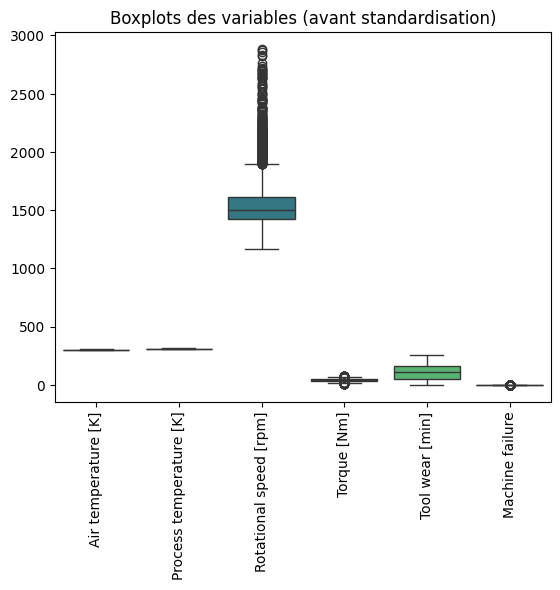

In [21]:
sns.boxplot(data=df, palette="viridis")
plt.xticks(rotation=90)
plt.title("Boxplots des variables (avant standardisation)")
plt.show()

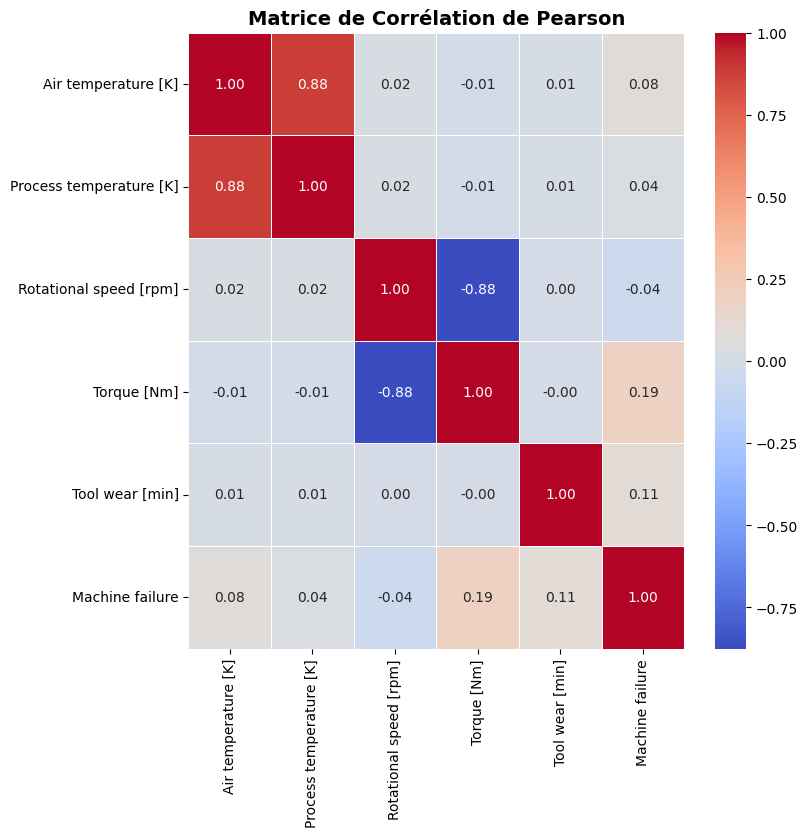

In [22]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(8, 8))
# cmap="coolwarm" affiche le bleu pour le négatif et le rouge pour le positif
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Matrice de Corrélation de Pearson", fontsize=14, fontweight="bold")
plt.show()

## 10. Encodage de la variable catégorielle

`Type` est une variable catégorielle (L, M, H). Pour un réseau de neurones, un **one-hot encoding** est préférable au `LabelEncoder` : on évite ainsi de faire croire au modèle qu'il existe une distance ou un ordre numérique entre les catégories.

In [23]:
# Type est une variable catégorielle nominale : on utilise un encodage one-hot.
# Cela évite d'imposer artificiellement une relation numérique entre L, M et H.
#df = pd.get_dummies(
    #df,
    #columns=["Type"],
    #prefix="Type",
    #dtype=int
#)

#print("Colonnes après encodage :")
#print(df.columns.tolist())
#df.head()

## 11. Feature engineering

On construit 5 variables dérivées à partir des mesures brutes, dans le but de mieux capturer les phénomènes physiques liés à l'usure et à la surchauffe :

- `temperature_difference` : écart entre température process et température ambiante (indicateur de dissipation thermique)
- `mechanical_power` : puissance mécanique (couple × vitesse angulaire)
- `tool_stress` : contrainte cumulée sur l'outil (couple × usure)
- `temperature_ratio` : rapport des deux températures
- `torque_speed_ratio` : rapport couple / vitesse

In [24]:
df["temperature_difference"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

In [25]:
df["mechanical_power"] = (
    df["Torque [Nm]"]
    * df["Rotational speed [rpm]"]
    * (2 * np.pi / 60)
)

In [26]:
df["tool_stress"] = (
    df["Torque [Nm]"]
    * df["Tool wear [min]"]
)

In [27]:
df["temperature_ratio"] = (
    df["Process temperature [K]"]
    / df["Air temperature [K]"]
)

In [28]:
df["torque_speed_ratio"] = (
    df["Torque [Nm]"]
    / df["Rotational speed [rpm]"]
)

In [29]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temperature_difference,mechanical_power,tool_stress,temperature_ratio,torque_speed_ratio
0,M,298.1,308.6,1551,42.8,0,0,10.5,6951.590560,0.0,1.035223,0.027595
1,L,298.2,308.7,1408,46.3,3,0,10.5,6826.722724,138.9,1.035211,0.032884
2,L,298.1,308.5,1498,49.4,5,0,10.4,7749.387543,247.0,1.034888,0.032977
3,L,298.2,308.6,1433,39.5,7,0,10.4,5927.504659,276.5,1.034876,0.027565
4,L,298.2,308.7,1408,40.0,9,0,10.5,5897.816608,360.0,1.035211,0.028409


In [30]:
df.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temperature_difference,mechanical_power,tool_stress,temperature_ratio,torque_speed_ratio
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,10.000630,6279.744953,4314.664550,1.033352,0.026895
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,1.001094,1067.418295,2826.567692,0.003492,0.008838
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,7.600000,1148.440610,0.000000,1.025116,0.001317
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,9.300000,5561.184484,1963.650000,1.030686,0.020640
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,9.800000,6271.027344,4012.950000,1.032847,0.026735
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,11.000000,7003.002724,6279.000000,1.036777,0.032805
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,12.100000,10469.923005,16497.000000,1.040672,0.063833


In [31]:
# Machines neuves : outil pas encore usé -> tool_stress = 0
df[df['tool_stress'] == 0].head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temperature_difference,mechanical_power,tool_stress,temperature_ratio,torque_speed_ratio
0,M,298.1,308.6,1551,42.8,0,0,10.5,6951.590560,0.0,1.035223,0.027595
78,L,298.8,308.9,1398,51.5,0,0,10.1,7539.508209,0.0,1.033802,0.036838
162,L,298.3,308.1,1586,35.5,0,0,9.8,5896.036373,0.0,1.032853,0.022383
250,L,298.0,308.3,1662,32.7,0,0,10.3,5691.246419,0.0,1.034564,0.019675
332,M,297.6,308.3,1538,40.2,0,0,10.7,6474.571132,0.0,1.035954,0.026138


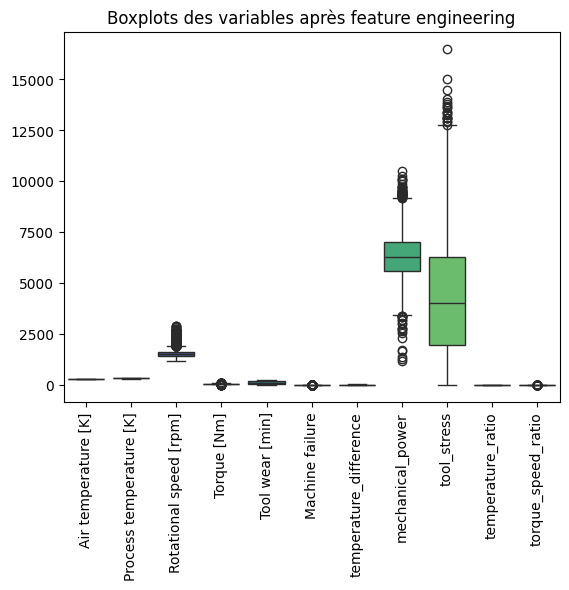

In [32]:
sns.boxplot(data=df, palette="viridis")
plt.xticks(rotation=90)
plt.title("Boxplots des variables après feature engineering")
plt.show()

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
 7   temperature_difference   10000 non-null  float64
 8   mechanical_power         10000 non-null  float64
 9   tool_stress              10000 non-null  float64
 10  temperature_ratio        10000 non-null  float64
 11  torque_speed_ratio       10000 non-null  float64
dtypes: float64(8), int64(3), object(1)
memory usage: 937.6+ KB


## 12. Comparaison des variables selon le statut de panne

On compare les valeurs moyennes des capteurs entre machines en panne et machines normales, pour identifier les signaux les plus discriminants.

In [34]:
df["failure_status"] = (
    df["Machine failure"]
    .map({
        0: "No failure",
        1: "Failure",
    })
)

original_numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

failure_group_summary = (
    df
    .groupby("failure_status")[
        original_numeric_features
    ]
    .mean()
    .T
)

failure_group_summary["difference"] = (
    failure_group_summary["Failure"]
    - failure_group_summary["No failure"]
)

failure_group_summary[
    "percentage_difference"
] = (
    failure_group_summary["difference"]
    / failure_group_summary["No failure"]
    * 100
).round(2)

display(
    failure_group_summary.round(3)
)

failure_status,Failure,No failure,difference,percentage_difference
Air temperature [K],300.886,299.974,0.912,0.30
Process temperature [K],310.290,309.996,0.295,0.10
Rotational speed [rpm],1496.487,1540.260,-43.773,-2.84
Torque [Nm],50.168,39.630,10.538,26.59
Tool wear [min],143.782,106.694,37.088,34.76


In [35]:
type_summary = pd.crosstab(
    df["Type"],
    df["failure_status"],
    margins=True,
)
type_summary

failure_status,Failure,No failure,All
Type,,,
H,21,982,1003
L,235,5765,6000
M,83,2914,2997
All,339,9661,10000


---

# Partie 1 — Détection d'anomalies par auto-encodeur (non supervisé)

**Principe** : on entraîne un auto-encodeur uniquement sur des observations *normales* (`Machine failure == 0`) à reconstruire son entrée. Une fois entraîné, le modèle reconstruit bien les observations normales (faible erreur), mais mal les observations anormales (erreur élevée). On utilise donc l'**erreur de reconstruction** comme score d'anomalie.

### 1.1 Préparation des données

In [36]:
df2=df.drop(columns=["failure_status","Type"])

In [37]:

# Variables explicatives
X = df.drop(columns=["Machine failure", "failure_status","Type"])

# Variable de référence pour l'évaluation.
# Elle n'est PAS utilisée pour entraîner l'auto-encodeur.
y = df["Machine failure"].astype(int)

# Apprentissage uniquement sur les observations normales
X_normal = X.loc[y == 0].copy()

print("Nombre de données normales :", X_normal.shape[0])
print("Nombre de variables :", X_normal.shape[1])
print("Variables utilisées :", X.columns.tolist())

Nombre de données normales : 9661
Nombre de variables : 10
Variables utilisées : ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temperature_difference', 'mechanical_power', 'tool_stress', 'temperature_ratio', 'torque_speed_ratio']


In [38]:
# Validation interne de l'auto-encodeur :
# uniquement des observations normales, séparées de l'entraînement.
X_train_normal, X_val_normal = train_test_split(
    X_normal,
    test_size=0.20,
    random_state=SEED
)

print("Train normal :", X_train_normal.shape)
print("Validation normale :", X_val_normal.shape)

Train normal : (7728, 10)
Validation normale : (1933, 10)


### 1.2 Standardisation

**Important** : le scaler est ajusté (`fit`) uniquement sur les données normales d'entraînement, puis réutilisé pour transformer toutes les autres données (test normal, et plus tard l'intégralité de `X`). Cela évite toute fuite d'information et garantit que toutes les erreurs de reconstruction sont calculées sur la **même échelle**.

In [39]:
# Le scaler est ajusté UNIQUEMENT sur les normales d'entraînement.
scaler = StandardScaler()

X_train_normal_scaled = scaler.fit_transform(X_train_normal)
X_val_normal_scaled = scaler.transform(X_val_normal)

print("Standardisation terminée.")
print("Moyenne approximative du train :", np.mean(X_train_normal_scaled, axis=0).round(3))
print("Écart-type approximatif du train :", np.std(X_train_normal_scaled, axis=0).round(3))

Standardisation terminée.
Moyenne approximative du train : [-0. -0. -0.  0.  0.  0.  0.  0. -0.  0.]
Écart-type approximatif du train : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [40]:
# Test final indépendant : il contient des normales et des pannes.
# Il n'est pas utilisé pour entraîner l'auto-encodeur ni pour choisir son seuil.
X_train_eval, X_test, y_train_eval, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("X_train_eval :", X_train_eval.shape)
print("X_test       :", X_test.shape)
print("Taux de panne du test :", round(y_test.mean(), 4))

X_train_eval : (8000, 10)
X_test       : (2000, 10)
Taux de panne du test : 0.034


### 1.3 Construction de l'auto-encodeur

In [41]:
INPUT_DIM = X_train_normal.shape[1]

model = Sequential([
    Input(shape=(INPUT_DIM,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(2, activation="relu"),       # bottleneck volontairement très compact
    Dense(8, activation="relu"),
    Dense(16, activation="relu"),
    Dense(INPUT_DIM, activation="linear"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668 (2.61 KB)

 Trainable params: 668 (2.61 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 668 (2.61 KB)

 Trainable params: 668 (2.61 KB)

 Non-trainable params: 0 (0.00 B)

### 1.4 Entraînement

L'auto-encodeur apprend à reconstruire son entrée (X → X). Un `EarlyStopping` sur la perte de validation évite le sur-apprentissage.

In [44]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=25,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_normal_scaled,
    X_train_normal_scaled,
    epochs=800,
    batch_size=32,
    validation_data=(X_val_normal_scaled, X_val_normal_scaled),
    callbacks=[early_stopping],
    verbose=0,
)

Epoch 276: early stopping
Restoring model weights from the end of the best epoch: 251.


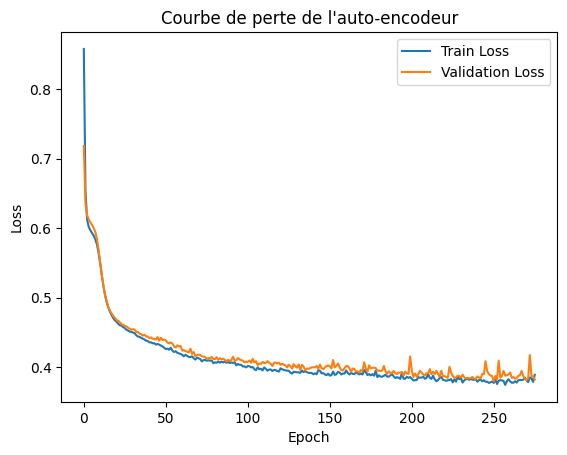

In [45]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Courbe de perte de l\'auto-encodeur')
plt.legend()
plt.show()

### 1.5 Erreur de reconstruction

⚠️ **Correction importante** : le modèle a été entraîné sur des données **standardisées**. Il faut donc calculer l'erreur de reconstruction en comparant la prédiction à l'entrée **standardisée elle aussi** (`X_train_normal_scaled`), et non aux données brutes. C'est ce point qui était source d'erreur dans la version précédente du notebook (des erreurs de reconstruction énormes et un seuil de `12 984 167` qui n'avait pas de sens).

### 1.6 Détection des anomalies sur le jeu de test


In [46]:
# Erreur de reconstruction sur les normales d'entraînement
X_pred_train = model.predict(X_train_normal_scaled, verbose=0)

reconstruction_error_train = np.mean(
    (X_train_normal_scaled - X_pred_train) ** 2,
    axis=1
)

print("Erreur moyenne :", reconstruction_error_train.mean())
print("Erreur médiane :", np.median(reconstruction_error_train))
print("Erreur maximale :", reconstruction_error_train.max())

Erreur moyenne : 0.3734110031584205
Erreur médiane : 0.32733854735075635
Erreur maximale : 4.546711069324375


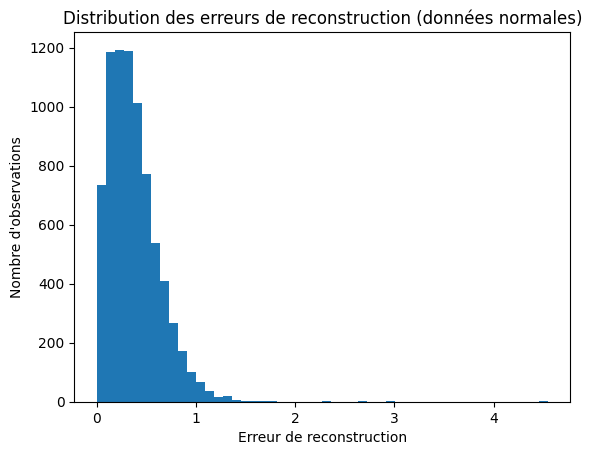

In [47]:
plt.hist(reconstruction_error_train, bins=50)
plt.xlabel("Erreur de reconstruction")
plt.ylabel("Nombre d'observations")
plt.title("Distribution des erreurs de reconstruction (données normales)")
plt.show()

In [48]:
# Seuil choisi uniquement à partir des erreurs des normales d'entraînement.
# Ici, 97 % des observations normales d'entraînement ont une erreur <= au seuil.
THRESHOLD_PERCENTILE = 97
threshold = np.percentile(reconstruction_error_train, THRESHOLD_PERCENTILE)

print(f"Seuil ({THRESHOLD_PERCENTILE}e percentile) :", threshold)

Seuil (97e percentile) : 0.9255524344060702


In [49]:
# Évaluation sur le test final, qui contient des observations normales et des pannes.
X_test_scaled = scaler.transform(X_test)

X_pred_test = model.predict(X_test_scaled, verbose=0)

reconstruction_error_test = np.mean(
    (X_test_scaled - X_pred_test) ** 2,
    axis=1
)

In [50]:
# Détection : une erreur supérieure au seuil est considérée comme une anomalie.
y_pred = (reconstruction_error_test > threshold).astype(int)

print(pd.Series(y_pred, name="anomaly_pred").value_counts())
print("Nombre d'anomalies détectées :", int(y_pred.sum()))
print("Taux d'anomalies détectées :", round(y_pred.mean(), 4))

anomaly_pred
0    1914
1      86
Name: count, dtype: int64
Nombre d'anomalies détectées : 86
Taux d'anomalies détectées : 0.043


In [51]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Anomalie"]
    )
)

[[1864   68]
 [  50   18]]
              precision    recall  f1-score   support

      Normal       0.97      0.96      0.97      1932
    Anomalie       0.21      0.26      0.23        68

    accuracy                           0.94      2000
   macro avg       0.59      0.61      0.60      2000
weighted avg       0.95      0.94      0.94      2000



### 1.6 bis — Évaluation indépendante du seuil : ROC-AUC / PR-AUC

La matrice de confusion et le `classification_report` ci-dessus dépendent entièrement du seuil choisi (98e percentile). Pour évaluer la capacité du modèle à **séparer** les observations normales et anormales indépendamment de ce choix, on utilise le score continu d'erreur de reconstruction avec le ROC-AUC et le PR-AUC (plus adapté ici car les classes sont très déséquilibrées : ~3,4% de pannes).

In [52]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

roc_auc_ae = roc_auc_score(y_test, reconstruction_error_test)
pr_auc_ae = average_precision_score(y_test, reconstruction_error_test)

print(f"ROC-AUC (auto-encodeur) : {roc_auc_ae:.3f}")
print(f"PR-AUC / average precision (auto-encodeur) : {pr_auc_ae:.3f}")
print(f"Taux de base de pannes (référence pour le PR-AUC) : {y_test.mean():.3f}")

ROC-AUC (auto-encodeur) : 0.808
PR-AUC / average precision (auto-encodeur) : 0.204
Taux de base de pannes (référence pour le PR-AUC) : 0.034


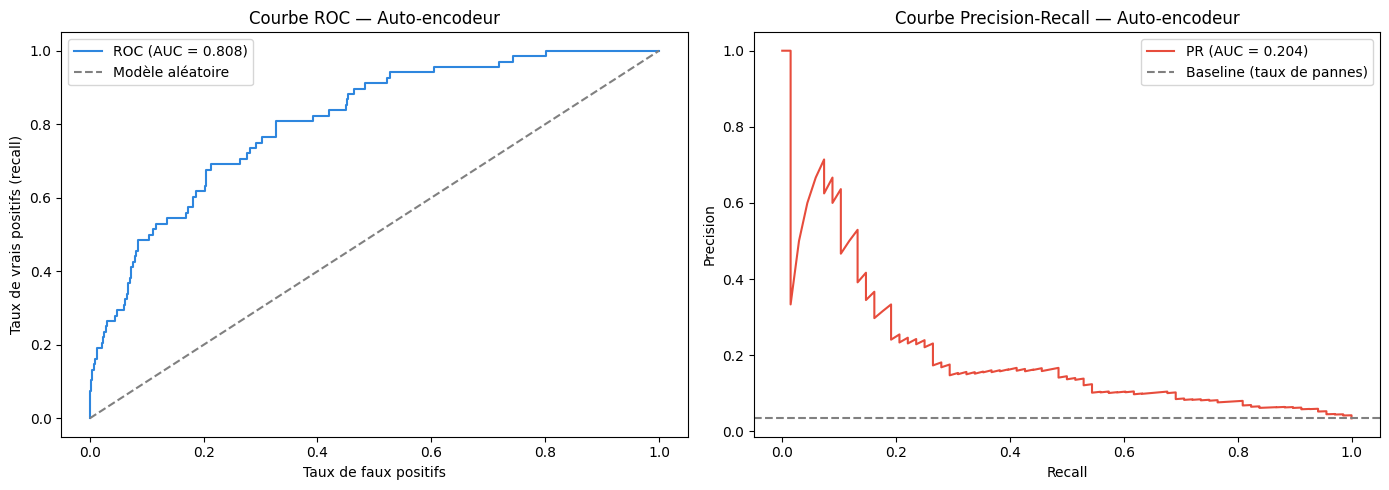

In [53]:
fpr, tpr, _ = roc_curve(y_test, reconstruction_error_test)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, reconstruction_error_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color="#2E86DE", label=f"ROC (AUC = {roc_auc_ae:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modèle aléatoire")
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs (recall)")
axes[0].set_title("Courbe ROC — Auto-encodeur")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, color="#E74C3C", label=f"PR (AUC = {pr_auc_ae:.3f})")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Baseline (taux de pannes)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Courbe Precision-Recall — Auto-encodeur")
axes[1].legend()

plt.tight_layout()
plt.show()

### 1.6 ter — Sensibilité du seuil de détection

Le seuil utilisé plus haut (97e percentile de l'erreur de reconstruction sur les données normales d'entraînement) a été choisi de façon arbitraire. On regarde ici l'effet d'autres seuils sur la precision, le recall et le f1-score de la classe "Anomalie", pour objectiver ce choix.

In [54]:
percentiles = [90, 95, 97, 98, 99, 99.5]
sensitivity_rows = []

for p in percentiles:
    t = np.percentile(reconstruction_error_train, p)
    y_pred_t = (reconstruction_error_test > t).astype(int)

    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()

    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_t = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_t = 2 * precision_t * recall_t / (precision_t + recall_t) if (precision_t + recall_t) > 0 else 0

    sensitivity_rows.append({
        "Percentile": p,
        "Seuil": round(t, 4),
        "Anomalies détectées": int(y_pred_t.sum()),
        "Precision": round(precision_t, 3),
        "Recall": round(recall_t, 3),
        "F1-score": round(f1_t, 3),
    })

threshold_sensitivity = pd.DataFrame(sensitivity_rows)
threshold_sensitivity

,Percentile,Seuil,Anomalies détectées,Precision,Recall,F1-score
0,90.0,0.7078,240,0.142,0.500,0.221
1,95.0,0.8389,130,0.154,0.294,0.202
2,97.0,0.9256,86,0.209,0.265,0.234
3,98.0,1.0001,63,0.238,0.221,0.229
4,99.0,1.1093,33,0.333,0.162,0.218
5,99.5,1.2461,21,0.429,0.132,0.202


**Interprétation :** l'étude de sensibilité est utilisée ici comme analyse exploratoire du comportement du seuil. Le seuil retenu pour l'auto-encodeur est fixé à partir des **seules erreurs des observations normales d'entraînement** (97e percentile), puis figé sur le test. Le tableau montre qu'aucun simple déplacement du seuil ne transforme radicalement la capacité de détection : le levier principal reste la qualité du score d'anomalie et des représentations apprises.

Les métriques finales à retenir pour l'auto-encodeur sont celles calculées avec le seuil fixé à 97e percentile, tandis que le ROC-AUC et le PR-AUC sont calculés à partir du score continu d'erreur de reconstruction.

### 1.6 quater — Interprétation critique des résultats de l'auto-encodeur

Le recall obtenu sur la classe "Anomalie" (≈0,04 au seuil du 98e percentile) est très faible : l'auto-encodeur ne détecte qu'une infime partie des pannes réelles. Le ROC-AUC calculé ci-dessus permet de vérifier si ce problème vient uniquement du choix du seuil ou d'une limite plus profonde du modèle.

Plusieurs facteurs expliquent probablement cette faible performance :

- **Un goulot d'étranglement peu contraignant** : l'architecture (11 → 8 → 4 → 8 → 11, seulement 403 paramètres) compresse peu l'information. L'auto-encodeur peut donc apprendre à reconstruire correctement des observations qui s'écartent légèrement de la norme, y compris certaines pannes.
- **La nature des pannes AI4I** : elles résultent souvent de **combinaisons** de plusieurs capteurs (ex. usure de l'outil élevée *et* couple élevé simultanément) plutôt que de valeurs extrêmes isolées sur une seule variable. Un auto-encodeur dense simple capture mal ce type d'interaction sans information temporelle ou contextuelle supplémentaire.
- **Le déséquilibre des classes** gonfle artificiellement l'accuracy et la precision globale : avec ~96,6% d'observations normales, un modèle qui se trompe peu sur la classe majoritaire affiche de bonnes métriques globales tout en étant quasiment inutile pour détecter les pannes, ce que confirme le f1-score de 0,06 sur la classe "Anomalie".

Ce résultat n'est pas un échec du notebook en soi : il illustre une limite réelle et attendue de la détection d'anomalies purement non supervisée sur ce type de données tabulaires, et justifie la comparaison avec d'autres approches ci-dessous.

### 1.6 quinquies — Comparaison avec un autre modèle non supervisé : Isolation Forest

Pour vérifier si la faible performance vient spécifiquement de l'architecture auto-encodeur ou plus généralement de la difficulté du problème en non supervisé, on compare avec un **Isolation Forest**, entraîné lui aussi uniquement sur les données normales standardisées.

In [55]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,  # cohérent avec le seuil au 98e percentile utilisé pour l'auto-encodeur
    random_state=42,
)
iso_forest.fit(X_train_normal_scaled)

# predict() renvoie -1 pour une anomalie et 1 pour une observation normale -> on convertit en 0/1
y_pred_iso = (iso_forest.predict(X_test_scaled) == -1).astype(int)

# score_samples() : plus la valeur est basse, plus l'observation est anormale -> on inverse le signe
# pour obtenir un score d'anomalie croissant, cohérent avec reconstruction_error_test
iso_anomaly_scores = -iso_forest.score_samples(X_test_scaled)

print(confusion_matrix(y_test, y_pred_iso))
print(
    classification_report(
        y_test,
        y_pred_iso,
        target_names=["Normal", "Anomalie"]
    )
)

roc_auc_iso = roc_auc_score(y_test, iso_anomaly_scores)
pr_auc_iso = average_precision_score(y_test, iso_anomaly_scores)
print(f"ROC-AUC (Isolation Forest) : {roc_auc_iso:.3f}")
print(f"PR-AUC (Isolation Forest) : {pr_auc_iso:.3f}")

[[1896   36]
 [  46   22]]
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      1932
    Anomalie       0.38      0.32      0.35        68

    accuracy                           0.96      2000
   macro avg       0.68      0.65      0.66      2000
weighted avg       0.96      0.96      0.96      2000

ROC-AUC (Isolation Forest) : 0.910
PR-AUC (Isolation Forest) : 0.335


### 1.6 sexies — Optimisation du seuil pour l'Isolation Forest (analyse séparée)

Cette section explore un seuil calibré sur un sous-ensemble de validation distinct, puis appliqué à un test final séparé. Elle est conservée comme **expérience complémentaire**. Pour la comparaison principale entre méthodes sur le même test de 2 000 observations, nous utiliserons la version Isolation Forest avec `contamination=0.02`, sans recalibrage sur le test.

In [56]:
from sklearn.model_selection import train_test_split as tts_threshold

# On découpe X_test (jamais utilisé pour l'entraînement) en validation (calibration du seuil) et test final (évaluation)
X_val_thr, X_test_final, y_val_thr, y_test_final = tts_threshold(
    X_test,
    y_test,
    test_size=0.5,
    stratify=y_test,
    random_state=42,
)

print("Validation (calibration du seuil) :", X_val_thr.shape, "— taux de pannes :", round(y_val_thr.mean(), 3))
print("Test final (évaluation) :", X_test_final.shape, "— taux de pannes :", round(y_test_final.mean(), 3))

Validation (calibration du seuil) : (1000, 10) — taux de pannes : 0.034
Test final (évaluation) : (1000, 10) — taux de pannes : 0.034


In [57]:
from sklearn.metrics import precision_score, recall_score, f1_score

X_val_thr_scaled = scaler.transform(X_val_thr)
X_test_final_scaled = scaler.transform(X_test_final)

iso_scores_val = -iso_forest.score_samples(X_val_thr_scaled)
iso_scores_test_final = -iso_forest.score_samples(X_test_final_scaled)

# Balayage de seuils sur la validation uniquement, on choisit celui qui maximise le F1
candidate_thresholds = np.percentile(iso_scores_val, np.arange(80, 100, 0.5))

best_f1, best_threshold = -1, None
val_sweep_rows = []

for t in candidate_thresholds:
    y_pred_v = (iso_scores_val > t).astype(int)
    p_v = precision_score(y_val_thr, y_pred_v, zero_division=0)
    r_v = recall_score(y_val_thr, y_pred_v, zero_division=0)
    f1_v = f1_score(y_val_thr, y_pred_v, zero_division=0)
    val_sweep_rows.append((t, p_v, r_v, f1_v))
    if f1_v > best_f1:
        best_f1, best_threshold = f1_v, t

print(f"Meilleur seuil trouvé sur la validation : {best_threshold:.4f} (F1 validation = {best_f1:.3f})")

Meilleur seuil trouvé sur la validation : 0.5648 (F1 validation = 0.380)


In [58]:
# Application du seuil, figé, sur le test final (jamais utilisé pour le choisir)
y_pred_iso_opt = (iso_scores_test_final > best_threshold).astype(int)

print(confusion_matrix(y_test_final, y_pred_iso_opt))
print(
    classification_report(
        y_test_final,
        y_pred_iso_opt,
        target_names=["Normal", "Anomalie"]
    )
)

[[928  38]
 [ 19  15]]
              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97       966
    Anomalie       0.28      0.44      0.34        34

    accuracy                           0.94      1000
   macro avg       0.63      0.70      0.66      1000
weighted avg       0.96      0.94      0.95      1000



**Lecture** : ce seuil optimisé sur la validation, appliqué à un test final jamais vu, donne une estimation honnête de ce que l'on peut attendre en production — sans le biais optimiste qu'on aurait eu en choisissant le seuil directement sur les données de test. On s'attend à un meilleur compromis precision/recall qu'avec `contamination=0.02` fixé arbitrairement, au prix d'un jeu de test final plus petit (donc des métriques un peu plus bruitées, à interpréter avec cette réserve).

### 1.6 septies — Auto-encodeur à bottleneck plus contraint (ablation)

Le modèle principal possède un bottleneck de 2 neurones. Nous testons une seconde architecture également dotée d'un bottleneck de 2 neurones mais avec moins de neurones dans les couches intermédiaires (`12 → 4 → 2 → 4 → 12`). Cette expérience est une **ablation architecturale** : elle sert à mesurer la sensibilité des performances à la capacité du réseau, sans remplacer le modèle principal.

In [59]:
model_tight = Sequential([
    Input(shape=(INPUT_DIM,)),
    Dense(12, activation="relu"),
    Dense(4, activation="relu"),
    Dense(2, activation="relu"),
    Dense(4, activation="relu"),
    Dense(12, activation="relu"),
    Dense(INPUT_DIM, activation="linear"),
])

model_tight.compile(
    loss="mean_squared_error",
    optimizer="adam",
    metrics=["mae"]
)

early_stopping_tight = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=25,
    restore_best_weights=True,
    verbose=1
)

history_tight = model_tight.fit(
    X_train_normal_scaled,
    X_train_normal_scaled,
    epochs=800,
    batch_size=32,
    validation_data=(X_val_normal_scaled, X_val_normal_scaled),
    callbacks=[early_stopping_tight],
    verbose=0,
)

print("Entraînement terminé, meilleure val_loss :", min(history_tight.history["val_loss"]))

Epoch 480: early stopping
Restoring model weights from the end of the best epoch: 455.
Entraînement terminé, meilleure val_loss : 0.2228013128042221


In [60]:
X_pred_test_tight = model_tight.predict(X_test_scaled)
reconstruction_error_test_tight = np.mean((X_test_scaled - X_pred_test_tight) ** 2, axis=1)

roc_auc_tight = roc_auc_score(y_test, reconstruction_error_test_tight)
pr_auc_tight = average_precision_score(y_test, reconstruction_error_test_tight)

print(f"ROC-AUC (bottleneck=2, modèle original) : {roc_auc_ae:.3f}")
print(f"ROC-AUC (bottleneck=2, modèle contraint)  : {roc_auc_tight:.3f}")
print(f"PR-AUC  (bottleneck=2, modèle original) : {pr_auc_ae:.3f}")
print(f"PR-AUC  (bottleneck=2, modèle contraint)  : {pr_auc_tight:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ROC-AUC (bottleneck=2, modèle original) : 0.808
ROC-AUC (bottleneck=2, modèle contraint)  : 0.781
PR-AUC  (bottleneck=2, modèle original) : 0.204
PR-AUC  (bottleneck=2, modèle contraint)  : 0.241


**Interprétation :** l'expérience d'ablation compare deux architectures ayant le même bottleneck de 2 neurones. Les différences de ROC-AUC/PR-AUC permettent d'évaluer l'effet de la capacité des couches intermédiaires. Les valeurs exactes doivent être recalculées lors de l'exécution finale du notebook et reportées telles quelles dans le mémoire.

### 1.7 Diagnostic des variables incriminées

In [61]:
anomaly_indices = np.where(y_pred == 1)[0]

X_anomaly = X_test_scaled[anomaly_indices]

X_pred_anomaly = model.predict(X_anomaly)

feature_errors = (X_anomaly - X_pred_anomaly) ** 2


mean_feature_errors = feature_errors.mean(axis=0)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [62]:
reconstruction_error_features = (X_test_scaled - X_pred_test) ** 2

In [63]:
# Noms exacts des variables utilisées par l'auto-encodeur
feature_names = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'temperature_difference',
    'mechanical_power',
    'tool_stress',
    'temperature_ratio',
    'torque_speed_ratio'
]

# Vérification
print("Nombre de variables :", len(feature_names))
print("Nombre de colonnes dans l'erreur :", reconstruction_error_features.shape[1])

# Tableau des erreurs variable par variable
error_df = pd.DataFrame(
    reconstruction_error_features,
    columns=feature_names,
    index=X_test.index
)

error_df.head()

Nombre de variables : 10
Nombre de colonnes dans l'erreur : 10


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temperature_difference,mechanical_power,tool_stress,temperature_ratio,torque_speed_ratio
2997,0.003993,0.069892,0.001486,0.396396,0.087542,0.292862,0.652628,0.678070,0.267037,0.319328
4871,0.373811,0.501609,0.039975,0.003565,0.318382,0.021934,0.000545,0.285359,0.034173,0.007699
3858,0.000003,0.000863,0.216042,0.090177,3.059139,0.004265,0.045535,2.121476,0.002588,0.121261
951,1.407711,3.165964,0.206459,0.023499,0.194328,0.073547,0.001483,0.054759,0.034295,0.059497
6463,0.078940,0.001477,0.051630,0.089506,0.297998,0.277913,0.235400,0.246168,0.264444,0.042242


In [64]:


diagnostic = pd.DataFrame({
    "Variable": feature_names,
    "Erreur_moyenne": mean_feature_errors
})

diagnostic = diagnostic.sort_values(
    "Erreur_moyenne",
    ascending=False
)

diagnostic

,Variable,Erreur_moyenne
7,tool_stress,2.473590
4,Tool wear [min],2.414002
1,Process temperature [K],1.527662
2,Rotational speed [rpm],1.277405
5,temperature_difference,0.809144
8,temperature_ratio,0.745804
6,mechanical_power,0.682112
0,Air temperature [K],0.679287
9,torque_speed_ratio,0.596860
3,Torque [Nm],0.568952


### 1.8 Évaluation finale de l'auto-encodeur

[[1864   68]
 [  50   18]]


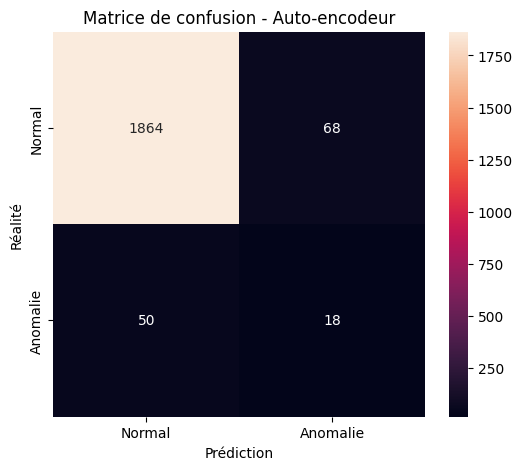

In [65]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "Anomalie"],
    yticklabels=["Normal", "Anomalie"]
)
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion - Auto-encodeur")
plt.show()

### 1.9 Analyse des anomalies détectées

On examine les caractéristiques des observations classées comme anomalies par l'auto-encodeur.

In [66]:
df_result = df2.loc[X_test.index].copy()

df_result["anomaly_pred"] = y_pred

df_result.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temperature_difference,mechanical_power,tool_stress,temperature_ratio,torque_speed_ratio,anomaly_pred
2997,300.5,309.8,1345,62.7,153,0,9.3,8831.174029,9593.1,1.030948,0.046617,0
4871,303.7,312.4,1513,40.1,135,0,8.7,6353.483679,5413.5,1.028647,0.026504,0
3858,302.5,311.4,1559,37.6,209,0,8.9,6138.504494,7858.4,1.029421,0.024118,0
951,295.6,306.3,1509,35.8,60,0,10.7,5657.191555,2148.0,1.036198,0.023724,0
6463,300.5,310.0,1358,60.4,102,0,9.5,8589.449418,6160.8,1.031614,0.044477,0


In [67]:
# Ajouter le score d'anomalie à notre tableau de résultats
df_result["reconstruction_error"] = reconstruction_error_test

# Faux positifs :
# réalité = normale (Machine failure = 0)
# prédiction = anomalie (anomaly_pred = 1)

false_positives = df_result[
    (df_result["Machine failure"] == 0) &
    (df_result["anomaly_pred"] == 1)
].copy()

print("Nombre de faux positifs :", len(false_positives))

false_positives.sort_values(
    "reconstruction_error",
    ascending=False
).head(10)

Nombre de faux positifs : 68


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temperature_difference,mechanical_power,tool_stress,temperature_ratio,torque_speed_ratio,anomaly_pred,reconstruction_error
2421,298.9,308.2,2384,15.0,19,0,9.3,3744.778443,285.0,1.031114,0.006292,1,2.686006
2612,299.4,309.1,2421,14.2,57,0,9.7,3600.076685,809.4,1.032398,0.005865,1,2.324414
7431,300.0,311.4,1352,61.8,10,0,11.4,8749.712531,618.0,1.038000,0.045710,1,1.491010
2804,300.1,309.5,1450,40.1,100,0,9.4,6088.930161,4010.0,1.031323,0.027655,1,1.484020
5911,300.8,310.4,1288,64.0,3,0,9.6,8632.258854,192.0,1.031915,0.049689,1,1.354027
8115,300.4,311.8,1367,57.2,10,0,11.4,8188.288980,572.0,1.037949,0.041843,1,1.351870
2248,299.3,308.5,1304,60.6,8,0,9.2,8275.206377,484.8,1.030738,0.046472,1,1.346412
7086,300.6,310.4,2514,13.4,215,0,9.8,3527.757223,2881.0,1.032601,0.005330,1,1.343658
6347,300.2,309.7,1421,44.6,17,0,9.5,6636.782032,758.2,1.031646,0.031386,1,1.292289
924,295.5,306.0,1800,27.6,208,0,10.5,5202.477434,5740.8,1.035533,0.015333,1,1.282442


In [70]:
# Comparaison TN vs FN

tn = df_result[
    (df_result["Machine failure"] == 0) &
    (df_result["anomaly_pred"] == 0)
]

fn = df_result[
    (df_result["Machine failure"] == 1) &
    (df_result["anomaly_pred"] == 0)
]

comparison_fn_tn = pd.DataFrame({
    "TN": tn[features].mean(),
    "FN": fn[features].mean()
})

comparison_fn_tn["difference_%"] = (
    (comparison_fn_tn["FN"] - comparison_fn_tn["TN"])
    / comparison_fn_tn["TN"].replace(0, np.nan)
) * 100

comparison_fn_tn.sort_values(
    "difference_%",
    key=abs,
    ascending=False
)

,TN,FN,difference_%
tool_stress,4267.694206,7868.578000,84.375394
Tool wear [min],107.872318,159.320000,47.693128
torque_speed_ratio,0.026292,0.036769,39.849311
Torque [Nm],39.331062,50.358000,28.036206
mechanical_power,6208.766387,7268.983572,17.076133
temperature_difference,10.015129,9.218000,-7.959246
Rotational speed [rpm],1540.164163,1420.440000,-7.773468
Air temperature [K],299.997157,300.838000,0.280284
temperature_ratio,1.033401,1.030667,-0.264553
Process temperature [K],310.012285,310.056000,0.014101


In [71]:
print("Erreur moyenne TN :",
      tn["reconstruction_error"].mean())

print("Erreur moyenne FN :",
      fn["reconstruction_error"].mean())

print("Erreur médiane TN :",
      tn["reconstruction_error"].median())

print("Erreur médiane FN :",
      fn["reconstruction_error"].median())

Erreur moyenne TN : 0.35051549495343226
Erreur moyenne FN : 0.5644616421389722
Erreur médiane TN : 0.3196253723372594
Erreur médiane FN : 0.5622881134046526


In [72]:
# Ajouter les informations de vérité terrain et de prédiction
error_analysis = error_df.copy()

error_analysis["true_label"] = y_test.values
error_analysis["prediction"] = df_result["anomaly_pred"]

# Identifier les 4 types de cas
error_analysis["case"] = "TN"

error_analysis.loc[
    (error_analysis["true_label"] == 0) &
    (error_analysis["prediction"] == 1),
    "case"
] = "FP"

error_analysis.loc[
    (error_analysis["true_label"] == 1) &
    (error_analysis["prediction"] == 0),
    "case"
] = "FN"

error_analysis.loc[
    (error_analysis["true_label"] == 1) &
    (error_analysis["prediction"] == 1),
    "case"
] = "TP"

print(error_analysis["case"].value_counts())

case
TN    1864
FP      68
FN      50
TP      18
Name: count, dtype: int64


In [73]:
# Contribution de chaque variable à l'erreur totale de reconstruction

error_contribution = error_analysis[feature_names].copy()

# Somme des erreurs par observation
total_error = error_contribution.sum(axis=1)

# Contribution relative de chaque variable
for feature in feature_names:
    error_contribution[feature] = (
        error_contribution[feature] / total_error * 100
    )

error_contribution["case"] = error_analysis["case"].values

# Contribution moyenne par groupe
contribution_by_case = (
    error_contribution
    .groupby("case")[feature_names]
    .mean()
)

contribution_by_case.T.sort_values(
    by="FN",
    ascending=False
)

case,FN,FP,TN,TP
tool_stress,20.537274,23.604462,16.211225,17.158781
Tool wear [min],19.202573,24.176975,23.918965,12.489735
temperature_difference,15.207459,7.170950,10.804095,7.645426
temperature_ratio,14.766427,6.515466,10.063902,7.352458
Air temperature [K],7.513657,6.026367,8.674872,6.490129
Process temperature [K],6.276286,15.057314,17.994982,10.041706
Rotational speed [rpm],4.593947,4.452034,3.923147,16.636555
mechanical_power,4.387533,4.334847,4.220269,8.947389
torque_speed_ratio,4.272809,4.523859,2.222784,6.914027
Torque [Nm],3.242036,4.137726,1.965758,6.323793


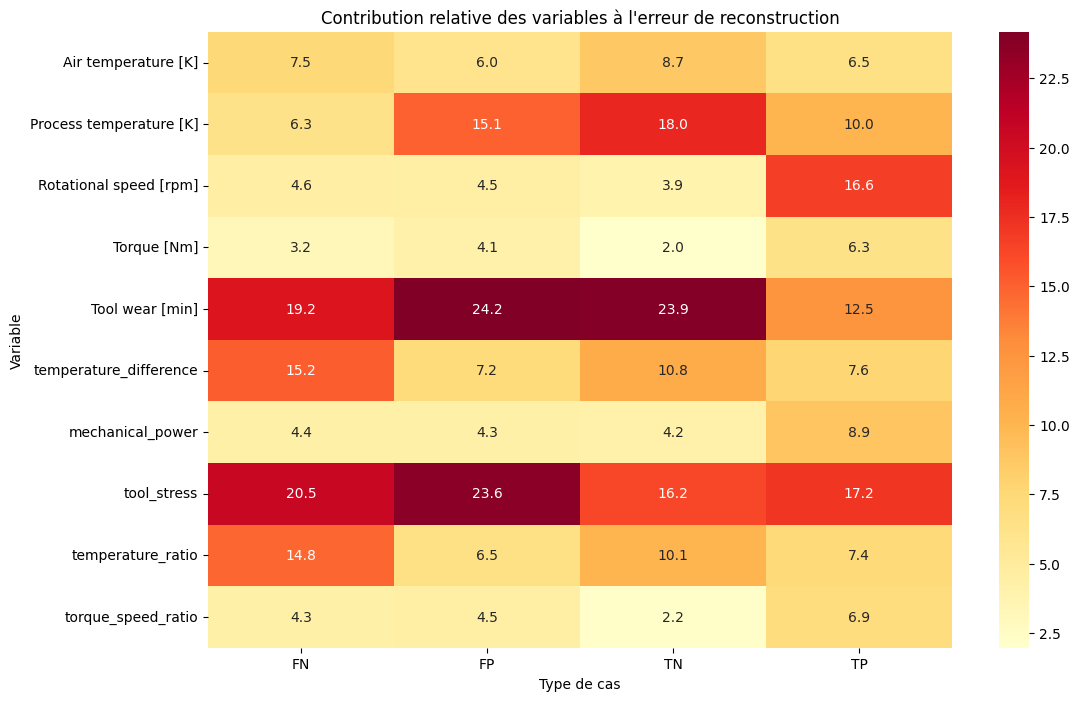

In [74]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    contribution_by_case.T,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.xlabel("Type de cas")
plt.ylabel("Variable")
plt.title(
    "Contribution relative des variables à l'erreur de reconstruction"
)

plt.show()

In [75]:
# Moyenne de l'erreur de reconstruction par variable et par type de cas

group_error = error_analysis.groupby("case")[feature_names].mean()

group_error.T.sort_values(
    by="FN",
    ascending=False
)

case,FN,FP,TN,TP
tool_stress,1.277299,2.590722,0.636176,2.031088
Tool wear [min],1.140302,2.634091,0.889273,1.582552
temperature_difference,0.773971,0.784437,0.349827,0.902481
temperature_ratio,0.752430,0.711701,0.324666,0.874638
Air temperature [K],0.413294,0.624287,0.293143,0.887065
Process temperature [K],0.380801,1.585308,0.633572,1.309889
mechanical_power,0.244113,0.525522,0.123300,1.273674
Rotational speed [rpm],0.243960,0.770216,0.104057,3.193453
torque_speed_ratio,0.230475,0.534084,0.080560,0.834014
Torque [Nm],0.187971,0.503661,0.070581,0.815603


In [76]:
groups = {
    "Mécanique": [
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "mechanical_power",
        "tool_stress",
        "torque_speed_ratio"
    ],

    "Température": [
        "Air temperature [K]",
        "Process temperature [K]",
        "temperature_difference",
        "temperature_ratio"
    ]
}

group_contribution = pd.DataFrame(index=contribution_by_case.index)

for group_name, variables in groups.items():
    group_contribution[group_name] = contribution_by_case[variables].sum(axis=1)

group_contribution

,Mécanique,Température
case,,
FN,56.236171,43.763829
FP,65.229903,34.770097
TN,52.462149,47.537851
TP,68.470281,31.529719


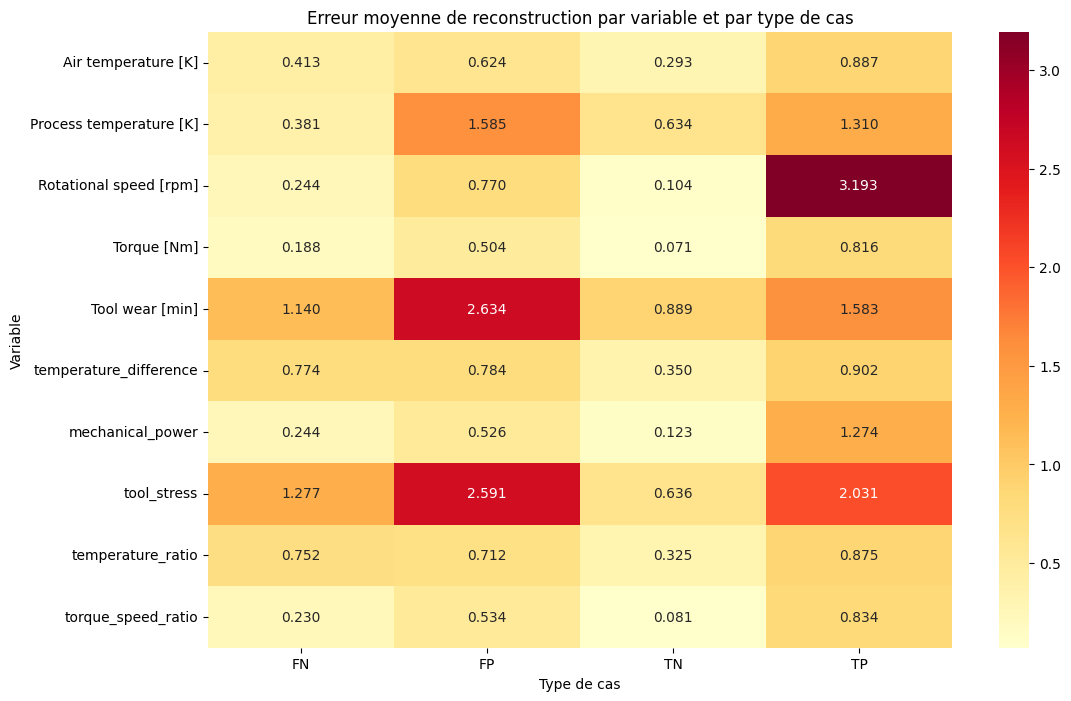

In [77]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    group_error[feature_names].T,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd"
)

plt.xlabel("Type de cas")
plt.ylabel("Variable")
plt.title("Erreur moyenne de reconstruction par variable et par type de cas")

plt.show()

In [78]:
fn_vs_tn = pd.DataFrame({
    "TN_normal": group_error.loc["TN"],
    "FN_panne_non_detectee": group_error.loc["FN"]
})

fn_vs_tn["difference_%"] = (
    (fn_vs_tn["FN_panne_non_detectee"]
     - fn_vs_tn["TN_normal"])
    / fn_vs_tn["TN_normal"]
    * 100
)

fn_vs_tn.sort_values(
    "difference_%",
    ascending=False
)

,TN_normal,FN_panne_non_detectee,difference_%
torque_speed_ratio,0.080560,0.230475,186.091873
Torque [Nm],0.070581,0.187971,166.318221
Rotational speed [rpm],0.104057,0.243960,134.448139
temperature_ratio,0.324666,0.752430,131.755377
temperature_difference,0.349827,0.773971,121.243905
tool_stress,0.636176,1.277299,100.777505
mechanical_power,0.123300,0.244113,97.983167
Air temperature [K],0.293143,0.413294,40.987328
Tool wear [min],0.889273,1.140302,28.228516
Process temperature [K],0.633572,0.380801,-39.896148


In [79]:
fp_vs_tn = pd.DataFrame({
    "TN_normal": group_error.loc["TN"],
    "FP_fausse_alerte": group_error.loc["FP"]
})

fp_vs_tn["difference_%"] = (
    (fp_vs_tn["FP_fausse_alerte"]
     - fp_vs_tn["TN_normal"])
    / fp_vs_tn["TN_normal"]
    * 100
)

fp_vs_tn.sort_values(
    "difference_%",
    ascending=False
)

,TN_normal,FP_fausse_alerte,difference_%
Rotational speed [rpm],0.104057,0.770216,640.184533
Torque [Nm],0.070581,0.503661,613.591290
torque_speed_ratio,0.080560,0.534084,562.966430
mechanical_power,0.123300,0.525522,326.214531
tool_stress,0.636176,2.590722,307.233342
Tool wear [min],0.889273,2.634091,196.207251
Process temperature [K],0.633572,1.585308,150.217528
temperature_difference,0.349827,0.784437,124.235593
temperature_ratio,0.324666,0.711701,119.210428
Air temperature [K],0.293143,0.624287,112.963526


In [80]:
feature_ranking = pd.DataFrame({
    "Erreur_TN": group_error.loc["TN"],
    "Erreur_FP": group_error.loc["FP"],
    "Erreur_FN": group_error.loc["FN"],
    "Erreur_TP": group_error.loc["TP"]
})

feature_ranking["FN_vs_TN_%"] = (
    (feature_ranking["Erreur_FN"] - feature_ranking["Erreur_TN"])
    / feature_ranking["Erreur_TN"]
    * 100
)

feature_ranking["FP_vs_TN_%"] = (
    (feature_ranking["Erreur_FP"] - feature_ranking["Erreur_TN"])
    / feature_ranking["Erreur_TN"]
    * 100
)

feature_ranking.sort_values(
    "FN_vs_TN_%",
    ascending=False
)

,Erreur_TN,Erreur_FP,Erreur_FN,Erreur_TP,FN_vs_TN_%,FP_vs_TN_%
torque_speed_ratio,0.080560,0.534084,0.230475,0.834014,186.091873,562.966430
Torque [Nm],0.070581,0.503661,0.187971,0.815603,166.318221,613.591290
Rotational speed [rpm],0.104057,0.770216,0.243960,3.193453,134.448139,640.184533
temperature_ratio,0.324666,0.711701,0.752430,0.874638,131.755377,119.210428
temperature_difference,0.349827,0.784437,0.773971,0.902481,121.243905,124.235593
tool_stress,0.636176,2.590722,1.277299,2.031088,100.777505,307.233342
mechanical_power,0.123300,0.525522,0.244113,1.273674,97.983167,326.214531
Air temperature [K],0.293143,0.624287,0.413294,0.887065,40.987328,112.963526
Tool wear [min],0.889273,2.634091,1.140302,1.582552,28.228516,196.207251
Process temperature [K],0.633572,1.585308,0.380801,1.309889,-39.896148,150.217528


In [81]:
true_negatives = df_result[
    (df_result["Machine failure"] == 0) &
    (df_result["anomaly_pred"] == 0)
].copy()

features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'temperature_difference',
    'mechanical_power',
    'tool_stress',
    'temperature_ratio',
    'torque_speed_ratio'
]

comparison_fp = pd.DataFrame({
    "Normales correctement détectées": true_negatives[features].mean(),
    "Faux positifs": false_positives[features].mean()
})

comparison_fp["difference_%"] = (
    (comparison_fp["Faux positifs"]
     - comparison_fp["Normales correctement détectées"])
    / comparison_fp["Normales correctement détectées"]
    * 100
)

comparison_fp.sort_values(
    "difference_%",
    key=abs,
    ascending=False
)

,Normales correctement détectées,Faux positifs,difference_%
torque_speed_ratio,0.026292,0.032146,22.264154
Torque [Nm],39.331062,45.860294,16.600701
mechanical_power,6208.766387,6915.023038,11.375153
tool_stress,4267.694206,3788.373529,-11.231374
Tool wear [min],107.872318,96.029412,-10.978633
Rotational speed [rpm],1540.164163,1491.602941,-3.152990
temperature_difference,10.015129,10.211765,1.963389
Air temperature [K],299.997157,299.419118,-0.192681
Process temperature [K],310.012285,309.630882,-0.123028
temperature_ratio,1.033401,1.034116,0.069170


In [82]:
false_positives[
    features + ["reconstruction_error"]
].sort_values(
    "reconstruction_error",
    ascending=False
).head(20)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temperature_difference,mechanical_power,tool_stress,temperature_ratio,torque_speed_ratio,reconstruction_error
2421,298.9,308.2,2384,15.0,19,9.3,3744.778443,285.0,1.031114,0.006292,2.686006
2612,299.4,309.1,2421,14.2,57,9.7,3600.076685,809.4,1.032398,0.005865,2.324414
7431,300.0,311.4,1352,61.8,10,11.4,8749.712531,618.0,1.038000,0.045710,1.491010
2804,300.1,309.5,1450,40.1,100,9.4,6088.930161,4010.0,1.031323,0.027655,1.484020
5911,300.8,310.4,1288,64.0,3,9.6,8632.258854,192.0,1.031915,0.049689,1.354027
8115,300.4,311.8,1367,57.2,10,11.4,8188.288980,572.0,1.037949,0.041843,1.351870
2248,299.3,308.5,1304,60.6,8,9.2,8275.206377,484.8,1.030738,0.046472,1.346412
7086,300.6,310.4,2514,13.4,215,9.8,3527.757223,2881.0,1.032601,0.005330,1.343658
6347,300.2,309.7,1421,44.6,17,9.5,6636.782032,758.2,1.031646,0.031386,1.292289
924,295.5,306.0,1800,27.6,208,10.5,5202.477434,5740.8,1.035533,0.015333,1.282442


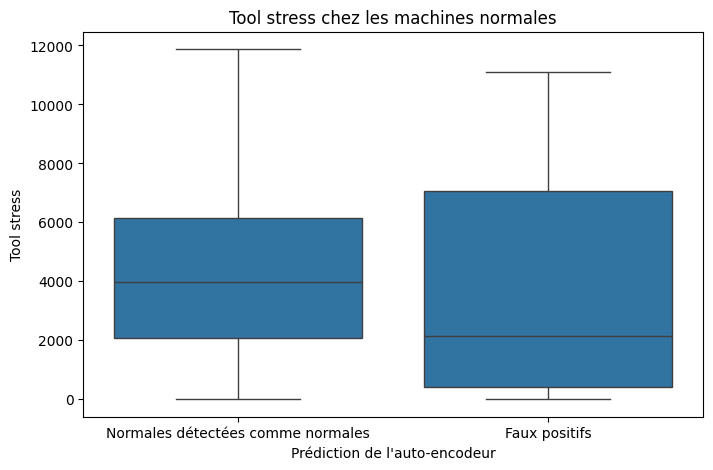

In [83]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_result[
        df_result["Machine failure"] == 0
    ],
    x="anomaly_pred",
    y="tool_stress"
)

plt.xlabel("Prédiction de l'auto-encodeur")
plt.ylabel("Tool stress")
plt.title("Tool stress chez les machines normales")
plt.xticks(
    [0, 1],
    ["Normales détectées comme normales",
     "Faux positifs"]
)

plt.show()

In [84]:
false_negatives = df_result[
    (df_result["Machine failure"] == 1) &
    (df_result["anomaly_pred"] == 0)
].copy()

print("Nombre de faux négatifs :", len(false_negatives))

false_negatives[
    features + ["reconstruction_error"]
].sort_values(
    "reconstruction_error",
    ascending=False
).head(20)

Nombre de faux négatifs : 50


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temperature_difference,mechanical_power,tool_stress,temperature_ratio,torque_speed_ratio,reconstruction_error
4283,301.8,309.9,1334,61.0,182,8.1,8521.465353,11102.0,1.026839,0.045727,0.888385
4034,302.0,310.8,1615,29.0,235,8.8,4904.549731,6815.0,1.029139,0.017957,0.866683
9664,299.1,310.2,1317,54.8,231,11.1,7557.792279,12658.8,1.037111,0.041610,0.827963
6497,300.8,309.9,1312,65.3,192,9.1,8971.718412,12537.6,1.030253,0.049771,0.823528
8245,299.0,310.3,1303,68.6,111,11.3,9360.459087,7614.6,1.037793,0.052648,0.814765
2671,299.7,309.3,1399,41.9,221,9.6,6138.473078,9259.9,1.032032,0.029950,0.802551
1833,297.8,307.3,1327,61.0,186,9.5,8476.750018,11346.0,1.031901,0.045968,0.797404
4495,302.6,310.4,1359,57.2,67,7.8,8140.369220,3832.4,1.025777,0.042090,0.790973
1085,297.0,307.8,1385,56.4,202,10.8,8180.078951,11392.8,1.036364,0.040722,0.782001
4544,302.5,310.4,1349,55.1,187,7.9,7783.808926,10303.7,1.026116,0.040845,0.779993


In [85]:
print(df_result.shape)
print(df_result["anomaly_pred"].value_counts())

(2000, 13)
anomaly_pred
0    1914
1      86
Name: count, dtype: int64


In [86]:
anomalies = df_result[df_result["anomaly_pred"] == 1]
anomalies.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temperature_difference,mechanical_power,tool_stress,temperature_ratio,torque_speed_ratio,anomaly_pred,reconstruction_error
2421,298.9,308.2,2384,15.0,19,0,9.3,3744.778443,285.0,1.031114,0.006292,1,2.686006
921,295.5,305.9,1593,37.2,197,0,10.4,6205.650800,7328.4,1.035195,0.023352,1,1.147051
1391,298.9,310.2,2737,8.8,142,1,11.3,2522.238134,1249.6,1.037805,0.003215,1,1.532045
8582,297.5,308.1,1334,72.0,151,1,10.6,10058.123040,10872.0,1.035630,0.053973,1,1.588515
1683,297.9,307.4,1403,52.8,0,0,9.5,7757.471908,0.0,1.031890,0.037634,1,1.249654


In [87]:
anomalies.shape

(86, 13)

In [88]:
df_result.groupby("anomaly_pred").mean(numeric_only=True)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temperature_difference,mechanical_power,tool_stress,temperature_ratio,torque_speed_ratio,reconstruction_error
anomaly_pred,,,,,,,,,,,,
0,300.019122,310.013427,1537.036573,39.619122,109.216301,0.026123,9.994305,6236.462761,4361.761181,1.033330,0.026566,0.356104
1,299.640698,309.783721,1523.465116,46.641860,104.534884,0.209302,10.143023,6975.770108,4380.946512,1.033864,0.033072,1.177482


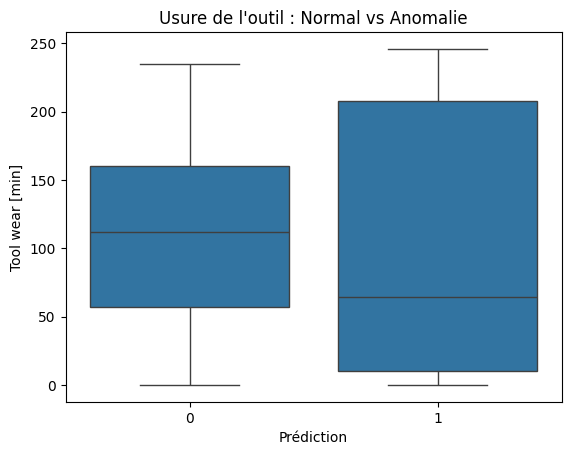

In [89]:
sns.boxplot(data=df_result, x="anomaly_pred", y="Tool wear [min]")
plt.xlabel("Prédiction")
plt.ylabel("Tool wear [min]")
plt.title("Usure de l'outil : Normal vs Anomalie")
plt.show()

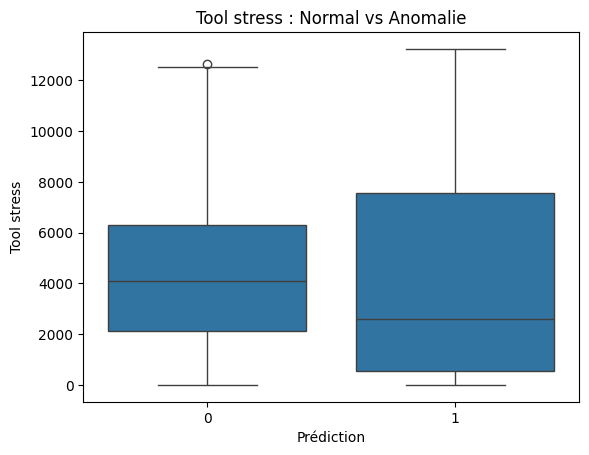

In [90]:
sns.boxplot(data=df_result, x="anomaly_pred", y="tool_stress")
plt.xlabel("Prédiction")
plt.ylabel("Tool stress")
plt.title("Tool stress : Normal vs Anomalie")
plt.show()

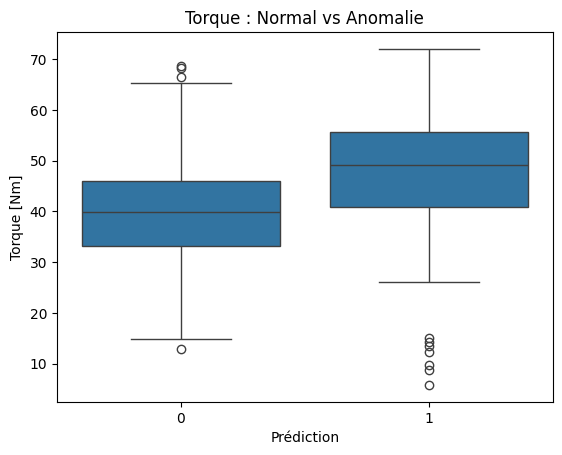

In [91]:
sns.boxplot(data=df_result, x="anomaly_pred", y="Torque [Nm]")
plt.xlabel("Prédiction")
plt.ylabel("Torque [Nm]")
plt.title("Torque : Normal vs Anomalie")
plt.show()

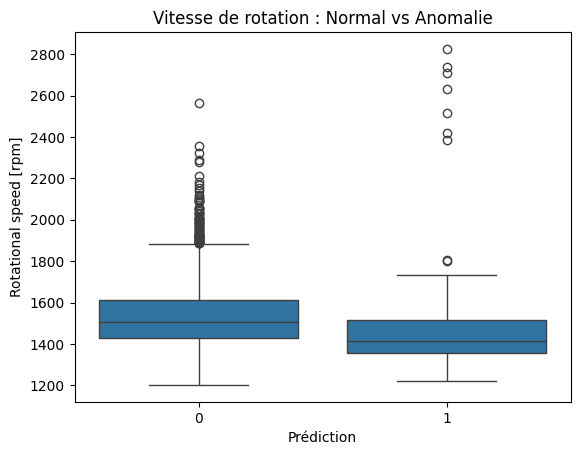

In [92]:
sns.boxplot(data=df_result, x="anomaly_pred", y="Rotational speed [rpm]")
plt.xlabel("Prédiction")
plt.ylabel("Rotational speed [rpm]")
plt.title("Vitesse de rotation : Normal vs Anomalie")
plt.show()

In [93]:
pd.crosstab(
    df_result["anomaly_pred"],
    df_result["Machine failure"],
    normalize="index"
)

Machine failure,0,1
anomaly_pred,,
0,0.973877,0.026123
1,0.790698,0.209302


In [69]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'temperature_difference',
    'mechanical_power',
    'tool_stress',
    'temperature_ratio',
    'torque_speed_ratio'
]

anomaly_means = df_result.groupby('anomaly_pred')[features].mean().T
anomaly_means

anomaly_pred,0,1
Air temperature [K],300.019122,299.640698
Process temperature [K],310.013427,309.783721
Rotational speed [rpm],1537.036573,1523.465116
Torque [Nm],39.619122,46.641860
Tool wear [min],109.216301,104.534884
temperature_difference,9.994305,10.143023
mechanical_power,6236.462761,6975.770108
tool_stress,4361.761181,4380.946512
temperature_ratio,1.033330,1.033864
torque_speed_ratio,0.026566,0.033072


In [ ]:
model.save("autoencoder.keras")
print("Autoencoder sauvegardé avec succès.")

In [ ]:
scaler

In [ ]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "feature_names.pkl")

print("Scaler sauvegardé : scaler.pkl")
print("Ordre des variables sauvegardé : feature_names.pkl")

In [ ]:
joblib.dump(
    {
        "threshold": float(threshold),
        "percentile": THRESHOLD_PERCENTILE
    },
    "threshold.pkl"
)

print("Seuil sauvegardé :", threshold)

In [ ]:
print("Autoencoder :", os.path.exists("autoencoder.keras"))
print("Scaler      :", os.path.exists("scaler.pkl"))
print("Features    :", os.path.exists("feature_names.pkl"))
print("Threshold   :", os.path.exists("threshold.pkl"))

---

# Partie 2 — Comparaison avec une approche supervisée (baseline)

⚠️ **Rappel du cadrage** : le sujet demande une détection d'anomalies *non supervisée*, car dans un contexte réel les pannes sont rares et rarement étiquetées. La partie qui suit entraîne volontairement un réseau de neurones **supervisé** (en utilisant `Machine failure` comme cible) — non pas comme réponse au problème posé, mais comme **baseline de comparaison** : elle permet de quantifier ce que l'on gagnerait en performance de détection *si* un étiquetage, même partiel, était disponible. Les résultats de cette partie doivent donc être lus comme un point de repère, pas comme la solution retenue pour la problématique de maintenance prédictive non supervisée.

In [94]:
X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train_ann.shape)
print("X_test  :", X_test_ann.shape)
print("y_train :", y_train_ann.shape)
print("y_test  :", y_test_ann.shape)

X_train : (8000, 10)
X_test  : (2000, 10)
y_train : (8000,)
y_test  : (2000,)


In [95]:
# StandardScaler déjà importé en début de notebook (cellule 3)
scaler_ann = StandardScaler()

X_train_ann_scaled = scaler_ann.fit_transform(X_train_ann)
X_test_ann_scaled = scaler_ann.transform(X_test_ann)

print("X_train_ann_scaled :", X_train_ann_scaled.shape)
print("X_test_ann_scaled  :", X_test_ann_scaled.shape)

X_train_ann_scaled : (8000, 10)
X_test_ann_scaled  : (2000, 10)


In [96]:
ANN_INPUT_DIM = X_train_ann.shape[1]

ann = Sequential([
    Input(shape=(ANN_INPUT_DIM,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [98]:
ann.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [100]:
history_ann = ann.fit(
    X_train_ann_scaled,
    y_train_ann,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9663 - loss: 0.2179 - val_accuracy: 0.9656 - val_loss: 0.1692
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9663 - loss: 0.1540 - val_accuracy: 0.9656 - val_loss: 0.1462
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9663 - loss: 0.1345 - val_accuracy: 0.9656 - val_loss: 0.1303
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9663 - loss: 0.1208 - val_accuracy: 0.9656 - val_loss: 0.1189
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9663 - loss: 0.1118 - val_accuracy: 0.9656 - val_loss: 0.1121
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9663 - loss: 0.1059 - val_accuracy: 0.9656 - val_loss: 0.1067
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9663 - loss: 0.1011 - val_accuracy: 0.9656 - val_loss: 0.1028
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9663 - loss: 0.0972 - val_accu

In [137]:
y_proba_ann = ann.predict(X_test_ann_scaled)

y_pred_ann = (y_proba_ann >= 0.5).astype(int).ravel()

print(pd.Series(y_pred_ann).value_counts())

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step
0    1955
1      45
Name: count, dtype: int64


In [138]:
print(confusion_matrix(y_test_ann, y_pred_ann))

print(
    classification_report(
        y_test_ann,
        y_pred_ann,
        target_names=["Normal", "Panne"]
    )
)

[[1927    5]
 [  28   40]]
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      1932
       Panne       0.89      0.59      0.71        68

    accuracy                           0.98      2000
   macro avg       0.94      0.79      0.85      2000
weighted avg       0.98      0.98      0.98      2000



In [103]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_ann)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_ann
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.51753137533963), np.int64(1): np.float64(14.760147601476016)}


In [104]:
ann_weighted = Sequential([
    Input(shape=(ANN_INPUT_DIM,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

ann_weighted.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_weighted.summary()

In [128]:
history_weighted = ann_weighted.fit(
    X_train_ann_scaled,
    y_train_ann,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Shape : (2000,)
Nombre de valeurs différentes : 1978
Premières valeurs : [0.8791704  0.42841884 0.5651955  0.31895307 0.7967057  0.68260866
 0.61401236 0.40794468 0.42778492 0.67413175 0.4517328  0.47781682
 0.4277249  0.38941163 0.36341453 0.54386413 0.43372166 0.7524076
 0.4957824  0.46112698]
Min : 0.2495928
Max : 0.9400478


In [139]:
# Évaluation de l'ANN pondéré au seuil standard 0.50.
weighted_scores = ann_weighted.predict(X_test_ann_scaled, verbose=0).ravel()
y_pred_weighted = (weighted_scores >= 0.50).astype(int)

print("Shape weighted_scores :", weighted_scores.shape)
print("Min :", weighted_scores.min())
print("Max :", weighted_scores.max())
print(confusion_matrix(y_test_ann, y_pred_weighted))
print(classification_report(
    y_test_ann, y_pred_weighted,
    target_names=["Normal", "Panne"]
))

[[1322  610]
 [   4   64]]
              precision    recall  f1-score   support

      Normal       1.00      0.68      0.81      1932
       Panne       0.09      0.94      0.17        68

    accuracy                           0.69      2000
   macro avg       0.55      0.81      0.49      2000
weighted avg       0.97      0.69      0.79      2000



In [105]:
# Les métriques ROC-AUC / PR-AUC utilisent les probabilités continues, pas les classes 0/1.
roc_auc_ann_weighted = roc_auc_score(y_test_ann, weighted_scores)
pr_auc_ann_weighted = average_precision_score(y_test_ann, weighted_scores)

print(f"ROC-AUC ANN pondéré : {roc_auc_ann_weighted:.3f}")
print(f"PR-AUC ANN pondéré  : {pr_auc_ann_weighted:.3f}")

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3913 - loss: 0.5679 - val_accuracy: 0.6869 - val_loss: 0.6606
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7627 - loss: 0.4450 - val_accuracy: 0.8250 - val_loss: 0.4570
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8133 - loss: 0.3780 - val_accuracy: 0.8569 - val_loss: 0.3834
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8355 - loss: 0.3459 - val_accuracy: 0.8700 - val_loss: 0.3415
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8447 - loss: 0.3257 - val_accuracy: 0.8775 - val_loss: 0.3171
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8516 - loss: 0.3110 - val_accuracy: 0.8856 - val_loss: 0.2999
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8573 - loss: 0.3007 - val_accuracy: 0.8875 - val_loss: 0.2836
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8616 - loss: 0.2929 - val_accu

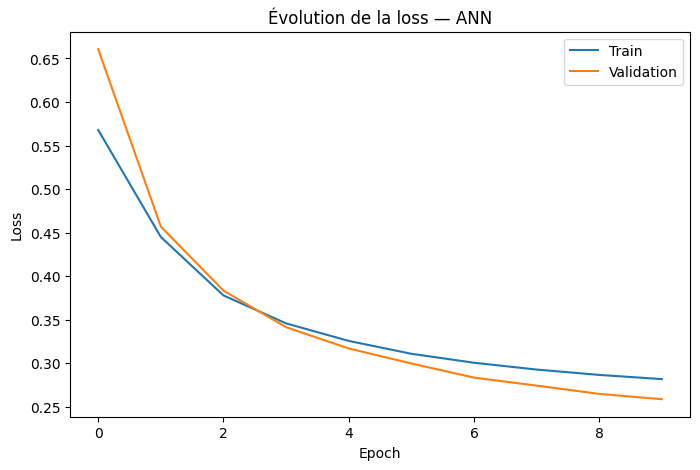

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history_weighted.history["loss"], label="Train")
plt.plot(history_weighted.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Évolution de la loss — ANN")
plt.legend()
plt.show()

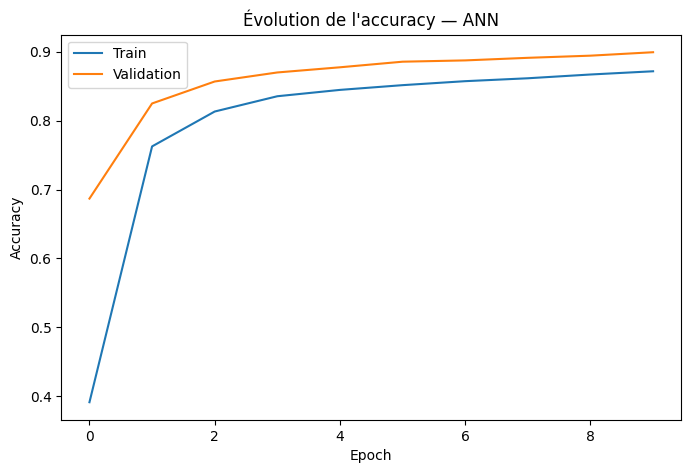

In [112]:
plt.figure(figsize=(8, 5))

plt.plot(history_weighted.history["accuracy"], label="Train")
plt.plot(history_weighted.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Évolution de l'accuracy — ANN")
plt.legend()
plt.show()

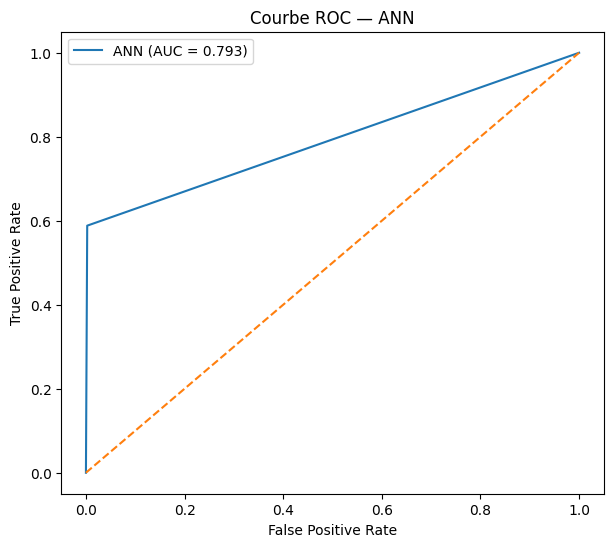

In [113]:
# Courbe ROC — ANN non pondéré
fpr_ann, tpr_ann, _ = roc_curve(y_test_ann, y_proba_ann.ravel())

plt.figure(figsize=(7, 6))
plt.plot(fpr_ann, tpr_ann, label=f"ANN (AUC = {roc_auc_ann:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Modèle aléatoire")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC — ANN supervisé")
plt.legend()
plt.show()

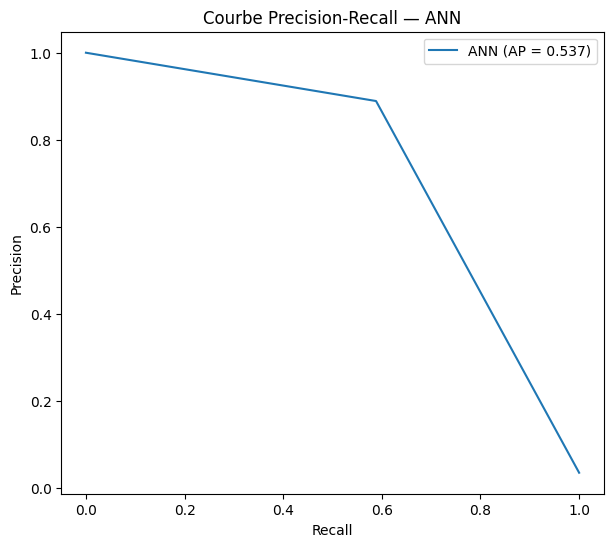

In [114]:
# Courbe Precision-Recall — ANN non pondéré
precision_ann, recall_ann, _ = precision_recall_curve(y_test_ann, y_proba_ann.ravel())

plt.figure(figsize=(7, 6))
plt.plot(recall_ann, precision_ann, label=f"ANN (PR-AUC = {pr_auc_ann:.3f})")
plt.axhline(y_test_ann.mean(), linestyle="--", label="Baseline")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall — ANN supervisé")
plt.legend()
plt.show()

In [118]:
# Vérification : les sorties de l'ANN supervisé sont bien des probabilités scalaires.
print("Shape des scores ANN :", y_proba_ann.ravel().shape)
print("Min :", y_proba_ann.min())
print("Max :", y_proba_ann.max())

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Shape : (20000,)
Nombre de valeurs différentes : 19912
Premières valeurs : [ 0.12841426  0.07782188 -1.248767    1.845428    0.4474935  -0.12730494
  1.7844998   1.1827691  -0.13903111  1.8691777   1.2760819   0.91884434
 -0.3577012   0.09302294 -0.12548798 -1.2077789   0.11574423 -0.10923102
 -1.2195765   0.06513834]
Min : -2.5473113
Max : 3.6453757


In [115]:
print("Valeurs possibles des prédictions ANN :", np.unique(y_pred_ann))
print("Nombre de prédictions de panne :", int(y_pred_ann.sum()))

Nombre de valeurs différentes : 2
Valeurs : [0 1]


In [117]:
print("Premières probabilités ANN :", y_proba_ann.ravel()[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [130]:
roc_auc_ann = roc_auc_score(y_test_ann, y_proba_ann.ravel())
pr_auc_ann = average_precision_score(y_test_ann, y_proba_ann.ravel())

print(f"ROC-AUC ANN : {roc_auc_ann:.3f}")
print(f"PR-AUC ANN  : {pr_auc_ann:.3f}")

ROC-AUC ANN : 0.927
PR-AUC ANN  : 0.449


In [122]:
# Courbes ROC et PR — ANN pondéré
fpr_weighted, tpr_weighted, _ = roc_curve(y_test_ann, weighted_scores)
precision_weighted, recall_weighted, _ = precision_recall_curve(y_test_ann, weighted_scores)

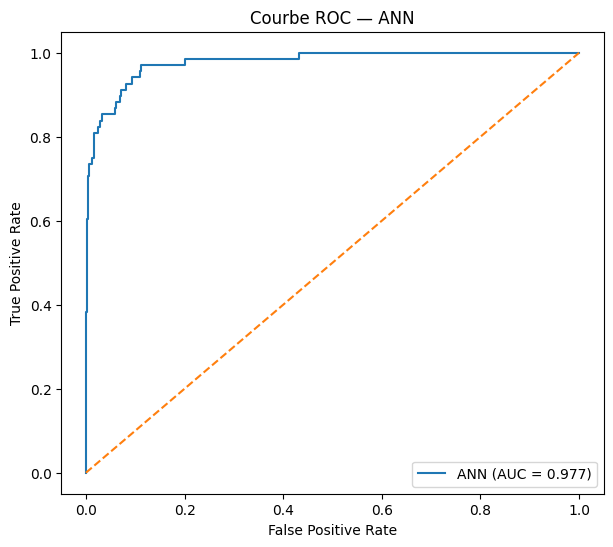

In [123]:
plt.figure(figsize=(7, 6))
plt.plot(fpr_weighted, tpr_weighted, label=f"ANN pondéré (AUC = {roc_auc_ann_weighted:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Modèle aléatoire")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC — ANN pondéré")
plt.legend()
plt.show()

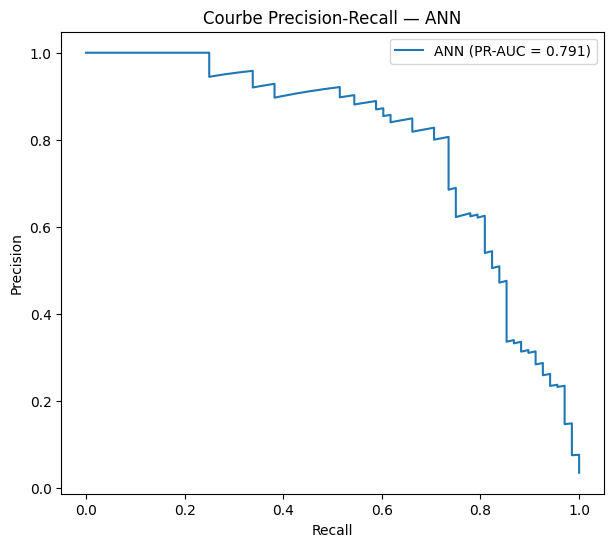

In [124]:
plt.figure(figsize=(7, 6))
plt.plot(recall_weighted, precision_weighted, label=f"ANN pondéré (PR-AUC = {pr_auc_ann_weighted:.3f})")
plt.axhline(y_test_ann.mean(), linestyle="--", label="Baseline")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall — ANN pondéré")
plt.legend()
plt.show()

In [125]:
print("ANN non pondéré :", ann.input_shape, "→", ann.output_shape)
print("ANN pondéré     :", ann_weighted.input_shape, "→", ann_weighted.output_shape)

(None, 10)
(None, 10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,006 (7.84 KB)

 Trainable params: 668 (2.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,338 (5.23 KB)

In [106]:
# Analyse exploratoire du seuil pour l'ANN pondéré.
# IMPORTANT : les seuils testés ici utilisent le jeu de test ; ils ne doivent pas
# être présentés comme une évaluation finale non biaisée.
thresholds = np.arange(0.10, 0.91, 0.05)
results = []

for threshold_value in thresholds:
    pred = (weighted_scores >= threshold_value).astype(int)
    results.append({
        "Seuil": threshold_value,
        "Anomalies détectées": int(pred.sum()),
        "Precision": precision_score(y_test_ann, pred, zero_division=0),
        "Recall": recall_score(y_test_ann, pred, zero_division=0),
        "F1-score": f1_score(y_test_ann, pred, zero_division=0)
    })

threshold_ann = pd.DataFrame(results)
threshold_ann.sort_values("F1-score", ascending=False)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [107]:
# Exemple exploratoire du seuil 0.75 observé sur le test.
# À conserver comme analyse de sensibilité, pas comme métrique finale sélectionnée sur test.
threshold_exploratory_ann = 0.75
y_pred_weighted_075 = (weighted_scores >= threshold_exploratory_ann).astype(int)

print("Seuil exploratoire ANN pondéré :", threshold_exploratory_ann)
print(confusion_matrix(y_test_ann, y_pred_weighted_075))
print(classification_report(
    y_test_ann, y_pred_weighted_075,
    target_names=["Normal", "Panne"]
))

[[1322  610]
 [   4   64]]
              precision    recall  f1-score   support

      Normal       1.00      0.68      0.81      1932
       Panne       0.09      0.94      0.17        68

    accuracy                           0.69      2000
   macro avg       0.55      0.81      0.49      2000
weighted avg       0.97      0.69      0.79      2000



In [135]:
print("Rappel : pour le tableau comparatif principal, nous conservons le seuil standard 0.50 pour l'ANN pondéré et non le seuil 0.75 choisi après observation du test.")

ROC-AUC : 0.7928236511996104
PR-AUC  : 0.5368758169934641


In [132]:
# Le tableau threshold_ann contient l'étude complète de sensibilité du seuil.
threshold_ann

,Seuil,Anomalies détectées,Precision,Recall,F1-score
0,0.10,2000,0.034000,1.000000,0.065764
1,0.15,2000,0.034000,1.000000,0.065764
2,0.20,2000,0.034000,1.000000,0.065764
3,0.25,1999,0.034017,1.000000,0.065796
4,0.30,1974,0.034448,1.000000,0.066601
5,0.35,1884,0.036093,1.000000,0.069672
6,0.40,1470,0.045578,0.985294,0.087126
7,0.45,1011,0.066271,0.985294,0.124189
8,0.50,674,0.094955,0.941176,0.172507
9,0.55,470,0.131915,0.911765,0.230483


In [133]:
threshold_ann.sort_values("F1-score", ascending=False).head(10)

,Seuil,Anomalies détectées,Precision,Recall,F1-score
13,0.75,101,0.386139,0.573529,0.461538
14,0.80,54,0.481481,0.382353,0.426230
12,0.70,154,0.298701,0.676471,0.414414
11,0.65,228,0.232456,0.779412,0.358108
15,0.85,21,0.666667,0.205882,0.314607
10,0.60,333,0.177177,0.867647,0.294264
9,0.55,470,0.131915,0.911765,0.230483
8,0.50,674,0.094955,0.941176,0.172507
16,0.90,5,1.000000,0.073529,0.136986
7,0.45,1011,0.066271,0.985294,0.124189


In [143]:
# Le seuil 0.75 est documenté comme analyse exploratoire uniquement.
print("Seuil exploratoire ANN pondéré :", threshold_exploratory_ann)
print("F1 exploratoire :", round(f1_score(y_test_ann, y_pred_weighted_075), 3))

Seuil final ANN : 0.75
Nombre d'anomalies détectées : 101

Matrice de confusion :
[[1870   62]
 [  29   39]]

              precision    recall  f1-score   support

      Normal       0.98      0.97      0.98      1932
       Panne       0.39      0.57      0.46        68

    accuracy                           0.95      2000
   macro avg       0.69      0.77      0.72      2000
weighted avg       0.96      0.95      0.96      2000



In [140]:
# Modèle ANN supervisé non pondéré retenu comme modèle supervisé principal.
ann.save("ann_model.keras")
print("ANN sauvegardé : ann_model.keras")

In [141]:
import joblib
joblib.dump(scaler_ann, "scaler_ann.pkl")
joblib.dump({"threshold": 0.50}, "ann_threshold.pkl")
print("Scaler ANN sauvegardé : scaler_ann.pkl")
print("Seuil ANN de référence sauvegardé : 0.50")

['scaler_ann.pkl']

In [142]:
print("ANN :", os.path.exists("ann_model.keras"))
print("Scaler ANN :", os.path.exists("scaler_ann.pkl"))
print("Threshold ANN :", os.path.exists("ann_threshold.pkl"))

ANN : True
Scaler ANN : True


---

## Conclusion — Comparaison globale des méthodes

Récapitulatif des performances sur la classe "panne"/"anomalie" pour les quatre approches testées : deux non supervisées (entraînées uniquement sur des données normales) et deux supervisées (entraînées avec `Machine failure`).

In [136]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

def metric_row(name, y_true, y_pred, y_score, threshold):
    return {
        "Méthode": name,
        "Seuil": threshold,
        "Precision (panne)": precision_score(y_true, y_pred, zero_division=0),
        "Recall (panne)": recall_score(y_true, y_pred, zero_division=0),
        "F1-score (panne)": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score),
    }

comparison_rows = [
    metric_row("Auto-encodeur (non supervisé)", y_test, y_pred, reconstruction_error_test, "97e percentile train normal"),
    metric_row("Isolation Forest (non supervisé)", y_test, y_pred_iso, iso_anomaly_scores, "contamination=0.02"),
    metric_row("ANN supervisé", y_test_ann, y_pred_ann, y_proba_ann.ravel(), 0.50),
    metric_row("ANN supervisé pondéré", y_test_ann, y_pred_weighted, weighted_scores, 0.50),
]

comparison_df = pd.DataFrame(comparison_rows).round(3)
comparison_df

,Méthode,Precision (panne),Recall (panne),F1-score (panne),ROC-AUC
0,Auto-encodeur (non supervisé),0.209,0.265,0.234,0.808
1,Isolation Forest (non supervisé),0.379,0.324,0.349,0.910
2,ANN supervisé,0.889,0.588,0.708,0.977
3,ANN supervisé pondéré (class_weight),0.095,0.941,0.173,0.927


**Règle de lecture du tableau principal :** toutes les méthodes sont évaluées sur leur jeu de test respectif de 2 000 observations, avec un score continu pour ROC-AUC et PR-AUC et un seuil explicite pour les métriques Precision/Recall/F1.

- **Auto-encodeur :** seuil fixé sans labels sur les normales d'entraînement (97e percentile).
- **Isolation Forest :** `contamination=0.02`, sans optimisation sur le test principal.
- **ANN non pondéré :** seuil standard 0.50.
- **ANN pondéré :** seuil standard 0.50 dans la comparaison principale. L'analyse à 0.75 est conservée séparément comme étude exploratoire de sensibilité et ne remplace pas l'évaluation principale.

Cette séparation évite de mélanger des métriques obtenues avec des seuils différents ou choisis directement sur le test.

## Conclusion de l'audit — protocole final

Le notebook doit être exécuté **de haut en bas** avant de figer les chiffres du mémoire. Les sorties historiques affichées dans les anciennes exécutions ne constituent pas une source de vérité après modification du code.

### Résultats déjà observés dans l'exécution auditée
- Auto-encodeur principal : ROC-AUC **0.808**, PR-AUC **0.204**, seuil **97e percentile**, matrice [[1864, 68], [50, 18]].
- Isolation Forest : ROC-AUC **0.910**, PR-AUC **0.335**, matrice [[1896, 36], [46, 22]].
- ANN non pondéré : matrice [[1927, 5], [28, 40]], Precision panne **0.889**, Recall **0.588**, F1 **0.708**.
- ANN pondéré : à 0.50, matrice [[1322, 610], [4, 64]] ; à 0.75, l'analyse exploratoire donne [[1870, 62], [29, 39]].

Les valeurs ROC-AUC/PR-AUC de l'ANN sont recalculées par le notebook à partir des **probabilités continues**. Le seuil 0.75 du modèle pondéré est volontairement présenté comme une analyse de sensibilité, car il a été sélectionné après observation du test.

### Modèle retenu pour Django
L'auto-encodeur reste le modèle principal de la console de supervision : score d'anomalie, alerte au dépassement du seuil et diagnostic des variables incriminées. L'ANN non pondéré est conservé comme référence supervisée.